In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/muthangisrirangasai/fwork-1/final_model.pt
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/run_ner.py
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/final_results.png
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/results.png
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/__results__.html
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/combined_test.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/tokenizer.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/combined_dev.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/best_finetuned_model.pt
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/tokenizer_config.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/__huggingface_repos__.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/history.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/summary.json
/kaggle/input/notebooks/muthangisrirangasai/fwork-1/inference_7000_results.csv
/kaggle/input/noteboo

In [2]:
import subprocess, sys, os, site

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"{'✅' if result.returncode == 0 else '❌'} {cmd[:70]}")
    if result.returncode != 0:
        print(result.stderr[-200:])

run("pip uninstall -y transformers accelerate datasets tokenizers huggingface-hub spacy-transformers")
run("pip uninstall -y transformers accelerate datasets tokenizers huggingface-hub spacy-transformers")
run("pip install --upgrade --force-reinstall --no-deps -q huggingface-hub==0.23.4")
run("pip install --upgrade --force-reinstall --no-deps -q tokenizers==0.19.1")
run("pip install --upgrade --force-reinstall --no-deps -q accelerate==0.28.0")
run("pip install --upgrade --force-reinstall --no-deps -q transformers==4.40.2")
run('pip install "en_legal_ner_trf @ https://huggingface.co/opennyaiorg/en_legal_ner_trf/resolve/main/en_legal_ner_trf-any-py3-none-any.whl" --no-deps')
run("pip install -q spacy-transformers==1.3.5 --no-deps")
run("pip install -q spacy-alignments")
run("pip install -q scikit-learn matplotlib seaborn")

for p in site.getsitepackages():
    if p not in sys.path:
        sys.path.insert(0, p)

mods = [m for m in sys.modules if any(
    m.startswith(p) for p in
    ['transformers','accelerate','tokenizers','huggingface_hub'])]
for m in mods: del sys.modules[m]

import accelerate, transformers
print(f"✅ accelerate  : {accelerate.__version__}")
print(f"✅ transformers: {transformers.__version__}")
print("✅ Cell 1 done")

✅ pip uninstall -y transformers accelerate datasets tokenizers huggingfa
✅ pip uninstall -y transformers accelerate datasets tokenizers huggingfa
✅ pip install --upgrade --force-reinstall --no-deps -q huggingface-hub==
✅ pip install --upgrade --force-reinstall --no-deps -q tokenizers==0.19.
✅ pip install --upgrade --force-reinstall --no-deps -q accelerate==0.28.
✅ pip install --upgrade --force-reinstall --no-deps -q transformers==4.4
✅ pip install "en_legal_ner_trf @ https://huggingface.co/opennyaiorg/en_
✅ pip install -q spacy-transformers==1.3.5 --no-deps
✅ pip install -q spacy-alignments
✅ pip install -q scikit-learn matplotlib seaborn
✅ accelerate  : 0.28.0
✅ transformers: 4.40.2
✅ Cell 1 done


✅ Found files at: /kaggle/input/notebooks/muthangisrirangasai/fwork-1/output

📁 All files:
   best_finetuned_model.pt — 438.8 MB
   best_model.pt — 438.8 MB
   final_model.pt — 438.8 MB
   final_results.png — 0.2 MB
   history.json — 0.0 MB
   inference_7000_results.csv — 0.4 MB
   results.png — 0.1 MB
   summary.json — 0.0 MB

Raw summary keys: ['pipeline', 'model', 'ner_model', 'input_format', 'train_samples', 'inference_cases', 'best_dev_f1', 'inference']
{
  "pipeline": "NER Entity Extraction + InLegalBERT Classification",
  "model": "law-ai/InLegalBERT",
  "ner_model": "en_legal_ner_trf (OpenNyAI)",
  "input_format": "[ENTITIES] {entities} [TEXT] {judgment}",
  "train_samples": 16152,
  "inference_cases": 7000,
  "best_dev_f1": 0.726788644568428,
  "inference": {
    "accuracy": 0.8787142857142857,
    "f1_macro": 0.8762845109852297,
    "precision": 0.8734649051729548,
    "recall": 0.8819631135151476,
    "roc_auc": 0.9504687061389301
  }
}

📈 Training History:
  Epoch | Train L

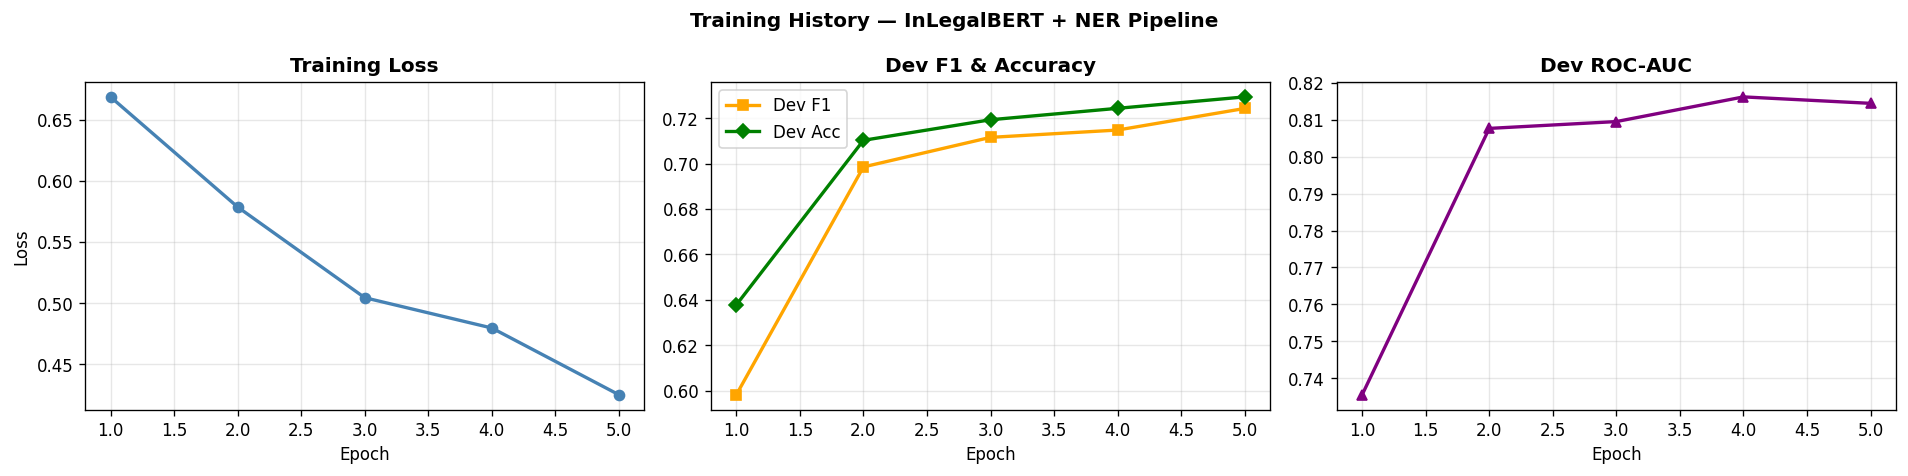

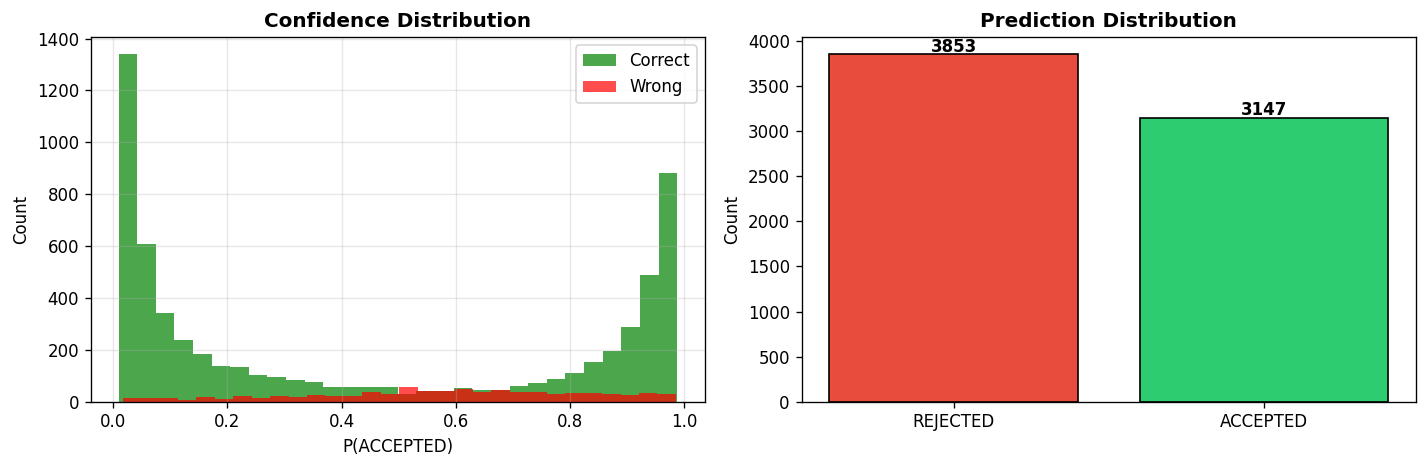

✅ Cell 2 done


In [3]:
import json, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

matplotlib.rcParams['figure.dpi'] = 120
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# ── Find input path ───────────────────────────────────────────
INPUT_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'best_finetuned_model' in f:
            INPUT_DIR = root
            break

print(f'✅ Found files at: {INPUT_DIR}')
print(f'\n📁 All files:')
for f in sorted(os.listdir(INPUT_DIR)):
    fpath = os.path.join(INPUT_DIR, f)
    if os.path.isfile(fpath):
        print(f'   {f} — {os.path.getsize(fpath)/1e6:.1f} MB')

# ── Load summary (handle both formats) ───────────────────────
with open(f'{INPUT_DIR}/summary.json') as f:
    summary = json.load(f)

print('\nRaw summary keys:', list(summary.keys()))
print(json.dumps(summary, indent=2))

# ── Load training history ─────────────────────────────────────
with open(f'{INPUT_DIR}/history.json') as f:
    history = json.load(f)

print(f'\n📈 Training History:')
print(f'  {"Epoch":>5} | {"Train Loss":>10} | {"Dev F1":>8} | {"Dev Acc":>8} | {"Dev AUC":>8}')
print(f'  {"-"*55}')
for i, (loss, f1, acc, auc) in enumerate(zip(
    history['train_loss'], history['dev_f1'],
    history['dev_acc'],    history['dev_auc']
)):
    marker = ' ← best' if f1 == max(history['dev_f1']) else ''
    print(f'  {i+1:>5} | {loss:>10.4f} | {f1:>8.4f} | '
          f'{acc:>8.4f} | {auc:>8.4f}{marker}')

# ── Load predictions CSV ──────────────────────────────────────
results_df = pd.read_csv(f'{INPUT_DIR}/inference_7000_results.csv')
print(f'\n📋 Predictions CSV ({len(results_df):,} rows):')
print(results_df.head(10).to_string(index=False))
print(f'\n  Prediction distribution:')
print(results_df['predicted'].value_counts().to_string())
print(f'\n  Correct: {results_df["correct"].sum():,} | '
      f'Wrong  : {(~results_df["correct"]).sum():,}')
print(f'  Accuracy: {results_df["correct"].mean()*100:.2f}%')

# ── Plot training curves ──────────────────────────────────────
epochs = list(range(1, len(history['train_loss'])+1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], 'o-',
             color='steelblue', lw=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['dev_f1'],  's-',
             color='orange', lw=2, label='Dev F1')
axes[1].plot(epochs, history['dev_acc'], 'D-',
             color='green',  lw=2, label='Dev Acc')
axes[1].set_title('Dev F1 & Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['dev_auc'], '^-',
             color='purple', lw=2)
axes[2].set_title('Dev ROC-AUC', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training History — InLegalBERT + NER Pipeline',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── Confidence distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

correct_df   = results_df[results_df['correct']]
incorrect_df = results_df[~results_df['correct']]

axes[0].hist(correct_df['prob_accepted'],
             bins=30, color='green', alpha=0.7, label='Correct')
axes[0].hist(incorrect_df['prob_accepted'],
             bins=30, color='red',   alpha=0.7, label='Wrong')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('P(ACCEPTED)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

label_counts = results_df['predicted'].value_counts()
colors = ['#e74c3c' if l == 'REJECTED' else '#2ecc71'
          for l in label_counts.index]
axes[1].bar(label_counts.index, label_counts.values,
            color=colors, edgecolor='black')
axes[1].set_title('Prediction Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (label, count) in enumerate(label_counts.items()):
    axes[1].text(i, count+30, str(count),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('✅ Cell 2 done')

In [4]:
import spacy, spacy_transformers
from collections import defaultdict

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL2ID  = {'REJECTED': 0, 'ACCEPTED': 1}
ID2LABEL  = {0: 'REJECTED', 1: 'ACCEPTED'}
ENTITY_PRIORITY = [
    'PETITIONER','RESPONDENT','COURT','JUDGE','STATUTE','PROVISION',
    'PRECEDENT','CASE_NUMBER','LAWYER','DATE','ORG','GPE',
    'OTHER_PERSON','WITNESS'
]
TEXT_TOKENS    = 448
NER_MAX_WORDS  = 400

# ── Model definition ──────────────────────────────────────────
class JudgmentClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden    = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        out    = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return {'logits': logits}

# ── Load tokenizer & model ────────────────────────────────────
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(f'{INPUT_DIR}/tokenizer')
print('✅ Tokenizer loaded')

print('Loading model weights...')
model = JudgmentClassifier('law-ai/InLegalBERT').to(DEVICE)
model.load_state_dict(
    torch.load(f'{INPUT_DIR}/best_finetuned_model.pt',
               map_location=DEVICE))
model.eval()
print(f'✅ Model loaded | device: {DEVICE}')

# ── Load NER ──────────────────────────────────────────────────
print('Loading NER model...')
spacy.require_gpu()
nlp_ner = spacy.load('en_legal_ner_trf')
print(f'✅ NER loaded | labels: {nlp_ner.get_pipe("ner").labels}')

# ── Prediction function ───────────────────────────────────────
def predict(text: str, true_label: str = None):
    """
    Pass any raw judgment text.
    Optionally pass true_label='ACCEPTED' or 'REJECTED' to check.
    """
    import transformers
    transformers.logging.set_verbosity_error()

    # Step 1: Pre-truncate for NER
    words = text.split()
    ner_text = ' '.join(words[:200] + words[-200:]) \
               if len(words) > NER_MAX_WORDS else text

    # Step 2: NER
    doc        = nlp_ner(ner_text)
    entity_map = defaultdict(list)
    for ent in doc.ents:
        entity_map[ent.label_.upper()].append(ent.text.strip())

    parts = []
    for etype in ENTITY_PRIORITY:
        if etype in entity_map:
            vals = list(dict.fromkeys(entity_map[etype]))[:2]
            parts.append(f'{etype}: {", ".join(vals)}')
    entity_str = ' | '.join(parts) if parts else 'NO_ENTITIES'

    # Step 3: Truncate judgment text
    toks = tokenizer.encode(text, add_special_tokens=False,
                             truncation=False)
    if len(toks) > TEXT_TOKENS:
        toks = toks[:64] + toks[-384:]
    truncated = tokenizer.decode(toks, skip_special_tokens=True)

    # Step 4: Combine & tokenize
    combined = f'[ENTITIES] {entity_str} [TEXT] {truncated}'
    enc = tokenizer(combined, max_length=512, padding='max_length',
                    truncation=True, return_tensors='pt')

    # Step 5: Predict
    with torch.no_grad():
        out  = model(enc['input_ids'].to(DEVICE),
                     enc['attention_mask'].to(DEVICE))
        prob = torch.softmax(out['logits'], dim=-1).squeeze().cpu().numpy()

    pred       = ID2LABEL[int(prob.argmax())]
    confidence = float(prob.max())

    # ── Print results ─────────────────────────────────────────
    print('\n' + '='*60)
    print('⚖️  COURT JUDGMENT PREDICTION')
    print('='*60)
    print(f'  Prediction   : {pred}')
    print(f'  Confidence   : {confidence:.2%}')
    print(f'  P(ACCEPTED)  : {prob[1]:.2%}')
    print(f'  P(REJECTED)  : {prob[0]:.2%}')
    if true_label:
        match = pred == true_label.upper()
        print(f'  True Label   : {true_label.upper()}')
        print(f'  Result       : {"✅ CORRECT" if match else "❌ WRONG"}')
    print(f'\n📋 Extracted Entities:')
    if parts:
        for p in parts:
            print(f'   {p}')
    else:
        print('   None extracted')
    print('='*60)
    transformers.logging.set_verbosity_warning()

print('\n✅ Cell 3 done — paste your judgment text below')

Loading tokenizer...
✅ Tokenizer loaded
Loading model weights...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/534M [00:00<?, ?B/s]

✅ Model loaded | device: cuda
Loading NER model...


/usr/local/lib/python3.12/dist-packages/spacy/util.py:969: UserWarning: [W095] Model 'en_legal_ner_trf' (3.2.0) was trained with spaCy v3.2.2 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/spacy_transformers/layers/hf_shim.py:137: UserWarning: Error loading saved torch state_dict with strict=True, likely due to differences between 'transformers' versions. Attempting to load with strict=False as a fallback...

If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current 'transformers' and 'spacy-transformers' versions. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


✅ NER loaded | labels: ('CASE_NUMBER', 'COURT', 'DATE', 'GPE', 'JUDGE', 'LAWYER', 'ORG', 'OTHER_PERSON', 'PETITIONER', 'PRECEDENT', 'PROVISION', 'RESPONDENT', 'STATUTE', 'WITNESS')

✅ Cell 3 done — paste your judgment text below


In [5]:
# ── Paste your judgment text here ────────────────────────────
MY_TEXT = """
CRIMINAL APPELLATE JURISDICTION Criminal Appeal No. 17 of 1951. Appeal against a Judgment and. Order dated 22nd January, 1951, of the High Court of Judicature at Patna (Imam J.) in Criminal Revision No. 1533 of 1950
P. Sinha (P.S. Safeer and K.N. Aggarwal, with him) for the appellants. The respondent did not appear. 1951. May 24. The Judgment of the Court was delivered by PATANJALI SASTRI J.--This is an appeal by special leave from an order of the High Court of Judicature at Patna setting aside an order of acquittal of the appellants by the Sessions Judge, Purnea, and directing their retrial.
The appellants were prosecuted for alleged offences under sections 147, 148, 323, 324, 326, 302 and 302/149 of the Indian Penal Code at the instance of one Polai Lal Biswas who lodged a complaint against them before the po- lice.
The prosecution case was that, while the complainant was harvesting the paddy crop on his field at about 10 a.m. on 29th November, 1949, a mob of about fifty persons came on to the field armed with ballams, lathis and other weapons and that the first appellant Logendranath Jha, who was leading the mob, demanded a settlement of all outstanding disputes with the complainant and ,said he would not allow the paddy to be removed unless the disputes were settled. An altercation followed as a result of which Logendra or- dered an assault by his men. Then Logendra and one of his men, Harihar, gave ballam blows to one of the labourers, Kangali, who fell down and died on the spot.
Information was given to the police who investigated the case and submitted the charge-sheet. The committing Magistrate found that a prima facie case was made out and committed the appellants to the Court of Sessions for trial. The appellants pleaded not guilty alleging inter alia, that Mohender and Debender, the brothers of Logendra (appel- lants 2 and 3) were not present in the village of Dandkhora with which they had no concern, as all the lands in that village had been allotted to Logendra at a previous parti- tion, that Logendra himself was not in the village at the time of the occurrence but arrived soon after and was dragged to the place at the instance of his enemies in the village and was placed under arrest by the Assistant Sub-Inspector of Police who had arrived there previously.
It was also alleged that there were two factions in the village, one of which was led by one Harimohan, a relation of the complainant, and the other by Logendra and there had been numerous revenue and criminal proceedings and long-standing enmity between the families of these leaders as a result of which this false case was foisted upon the appellants.
The learned Sessions Judge examined the evidence in great detail and found that the existence of factions as alleged by the appellants was true. He found, however, that the appellants plea of alibi was not satisfactorily made out, but the truth of the prosecution, he proceeded to observe, cannot be judged by the falsehood of the defence nor can the prosecution derive its strength from the weak- ness of the defence. Prosecution must stand on its own legs and must prove the story told by it at the very first stage. The manner of occurrence alleged by the prosecution must be established beyond doubt before the accused persons can be convicted.
Approaching the case in this manner and seeing that the basis of the prosecution case was that Polai had batai settlement of the disputed land and had raised the paddy crop which he was harvesting when the occurrence took place, the learned Sessions Judge examined the evidence of the prosecution witnesses who belonged to the opposite faction critically and found that the story of the prosecu- tion was not acceptable. Polai, who was alleged to have taken the land on batai settlement from his own maternal grandmother Parasmani who brought him up from his childhood, was only 19 years old and unmarried and was still living with his grandmother.
He did not claim to be a bataidar of any other person. In these circumstances, said the learned Judge, it does not appear to me to be probable that Polai would have been allowed to maintain himself by running adhi cultivation of his mamus land in the lifetime of his nani who has brought him up from his infancy like her own child. Nor does it appeal to me that the unmarried boy Polai would have undertaken upon himself the task of run- ning batai cultivation of the lands of his mamu where he has been living since his childhood without any trouble, more particularly in view of the heavy expenses of cultivation brought out by the evidence of Tirthanand (P.W. 14).
He, therefore, disbelieved the whole story that Polai had taken the lands of his grandmother or his uncles as bataidar for cultivation and that he was engaged in harvesting the paddy crop on the lands at the time of the occurrence.
This false story, in his opinion, vitally affected the prosecution case regarding the alleged manner of the occurrence. He also found a number of discrepancies and contradictions in the evidence of the prosecution witnesses, which, in his view, tended to show that the prosecution was guilty of concealment of the real facts.
In view of such conceal- ment of real facts, the learned Judge concluded, it does not appear to me to be possible to apportion liability and to decide which of the two parties commenced the fight and which acted in self-defence. Such being the position, it is not possible at all to hold either party responsible for what took place. In such a view of the matter coupled with the fact that the manner of occurrence alleged by the prose- cution has not been established to be true beyond doubt, I think that the accused persons cannot be safely convicted of any of the offences for which they have been charged.
The learned Judge accordingly acquitted the appellants of all the charges framed against them. Against that order the complainant Polai preferred a revision petition to the High Court under section 439 of the Criminal Procedure Code., The learned Judge who heard the petition reviewed the evidence at some length and came to the conclusion that the judgment of the learned Sessions Judge could not be allowed to stand as the acquittal of the appellants was perverse .
In his opinion, the entire judgment displays a lack of true perspective in a case of this kind. The Sessions Judge had completely misdirected himself in looking to the minor discrepancies in the case and ignoring the essential matters so far as the case is concerned, and there was no justifiable ground for rejecting the prosecution evidence regarding the cultivation and harvesting by Polai. And he concluded with the warning I would, however, make it per- fectly clear that when the case is re-tried, which I am now going to order, the Judge proceeding with the trial will not be in the least influenced by any expression of opinion which I may have given in this judgment.
On behalf of the appellants Mr. Sinha raised two conten- tions. In the first place, he submitted that having regard to section 417 of the Criminal Procedure Code which provides for an appeal to the High Court from an order of acquittal only at the instance of the Government, a revision petition under section 439 at the instance of a private party was incompetent, and, secondly, that sub-section (4) of section 439 clearly showed that the High Court exceeded its powers of revision in the present case in upsetting the findings of fact of the trial Judge.
We think it is unnecessary to express any opinion on the first contention of Mr. Sinha especially as the respondent is unrepresented, as we are of opinion that his second and alternative contention must prevail. It will be seen from the judgment summarised above that the learned Judge in the High Court re-appraised the evi- dence in the case and disagreed with the Sessions Judges findings of fact on the ground that they were perverse and displayed a lack of true perspective.
He went further and, by way of expressing in very clear terms as to how perverse the judgment of the court below is, he indicated that the discrepancies in the prosecution evidence and the circum- stances of the case which led the Sessions Judge to discred- it the prosecution story afforded no justifiable ground for the conclusion that the prosecution failed to establish their case.
We are of opinion that the learned Judge in the High Court did not properly appreciate the scope of inquiry in revision against an order of acquittal. Though sub-section(1) of section 439 authorises the High Court to exercise, in its discretion, any of the powers conferred on a court of appeal by section 423, sub-section (4) specifically excludes the power to convert a finding of acquittal into one. of conviction.
This does not mean that in dealing with a revision petition by a private party against an order of acquittal, the High Court could in the absence of any error on a point of law re-appraise the evidence and reverse the findings of facts on which the acquittal was based, provided only it stopped short of finding the accused guilty and passing sentence on him.
By merely characterising the judgment of the trial Court as perverse and lacking in perspective, the High Court cannot reverse pure findings of fact based on the trial Courts appreciation of the evidence in the case.
"""

# If you know the true label:
# predict(MY_TEXT, true_label='ACCEPTED')

# If you don't know:
predict(MY_TEXT)

2026-03-24 05:38:33.109208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774330713.485911      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774330713.595222      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774330714.557113      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774330714.557149      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774330714.557152      23 computation_placer.cc:177] computation placer alr


⚖️  COURT JUDGMENT PREDICTION
  Prediction   : ACCEPTED
  Confidence   : 97.23%
  P(ACCEPTED)  : 97.23%
  P(REJECTED)  : 2.77%

📋 Extracted Entities:
   PETITIONER: Logendranath Jha
   COURT: High Court of Judicature at Patna
   JUDGE: Imam, PATANJALI SASTRI
   STATUTE: Indian Penal Code
   PROVISION: sections 147, 148, 323, 324, 326, 302 and 302/149, sub-section(1) of section 439
   CASE_NUMBER: Criminal Appeal No. 17 of 1951, Criminal Revision No. 1533 of 1950
   DATE: 22nd January, 1951, 29th November, 1949
   OTHER_PERSON: P. Sinha, P.S. Safeer


CIVIL APPELLATE JURISDICTION Civil Appeal No. 90 of 1950. Appeal against the Judgment and Decree dated the 22nd July 1948 of the High Court of Judicature at Calcutta (K. C. Mitter, and K.C. Chunder J J) in appeal from Original Decree No. 49 of 1942 arising out of Decree dated the 8th September 1941 of the Subordi- nate Judge at Asansole in Suit No. 1 of 1941. Purusottam Chatterji (S. N. Mukherjee, with him) for the appellants. Panchanan Ghose, (P. C. Chatterjee, with him) for the respondent. 1951. May 4. the following judgments were delivered -- DAS J.--This appeal arises out of a suit filed by the appellants on January 2, 1941, in the Court of the Subordi- nate Judge, Asansole. That suit came to be filed in circum- stances which may now be stated shortly. A suit had been instituted by one Kumar Dakhineswar Malia against Rameswar Malia, Rani Bhaba Sundari and others for partition of the Searsole Raj Estate. One Bhagabati Charan Mitra was appointed receiver of that estate in that suit.
On August 10, 1908, the said receiver with the permis- sion of the Court which had appointed him as receiver grant- ed two mining leases, each for 999 years--one in respect of 5/16 share of the Malias in Mouza Monohar Bahal and the other in respect of 230 bighas in village Marich Kota--to a firm then carrying on business under the name and style of Laik Banerjee Company. On the same day the said receiver with like permission mortgaged these properties to the said firm as security for the due repayment of the loan of Rs. 100,000 advanced by that firm. The Malias joined the re- ceiver in executing the aforesaid leases and the mortgage.
As a result of these transactions the firm of Laik Banerjee Company became the lessees for 999 years of the two properties as well as the mortgagee of the lessors interest in the same. By diverse processes not necessary to be detailed, the appellants have become the successors in interest of the mortgagors and the respondent Deva Prasanna Mukerjee has become the successor in interest of the mortga- gee under the mortgage of August 10, 1908. On March 31, 1922, Deva Prasanna filed suit No. 78 of 1922 for enforcing the mortgage of 1908. Preliminary decree was passed in the last mentioned suit on July 31, 1928, and a final decree for sale was made I on February 26, 1929. In execution of this final decree the mortgaged properties were sold at a Court i sale and were purchased by Deva Prasanna for Rs. 59,000. This sale was confirmed by the Court on June 30, 1931. A large sum remaining still due to Deva Prasanna, he applied for, and on October 30, 1935, obtained a personal decree for Rs. 1,27,179-0-6 against Raja Pramatha Nath Malia who had by inheritance acquired the lessors interest and become the borrower. In 1936, Deva Prasanna started execution case No. 118 of 1936 for execution of the personal decree and attached certain properties alleging that the same belonged to the Raja. The exact date of the attachment does not appear from the printed record.
The Raja as Sibait of a certain deity and his two sons, the appellants before us, objected to the attachment of these properties and filed a claim case. Negotiations for settlement started and eventually, on January 30, 1937, a petition (Ex. 2) was filed in the exe- cuting Court stating as follows - The judgment debtor having made special requests to the decree-holder for an amicable settlement of the aforesaid execution case, the decree-holder has agreed to the same. But some time is required to settle the talks and all the terms etc. The judgment debtor has paid to the decree holder the costs of this execution amounting to Rs. 76-14-0, and he having made requests for this execution case being struck off for the present on keeping the attachment in force, the decreeholder has agreed to it. It is, therefore, prayed that under the circumstances aforesaid, the Court may be pleased to strike off this execution case keeping the attachment in force. Neither the original nor a certified copy of the order made on that date by the executing Court on the above petition is forthcoming but the parties have definite- ly agreed that the order is substantially and correctly entered in column 20 of Ex. F which is a certified copy of extract from the Register of applications for executions of decrees relating to execution Case No. 118 of 1936. The heading of column 20 is Date on which execution case was finally disposed of and purport of final order. The entry in column 20 under that head is
H. admits receipt of Rs. 76-14/- as costs of this case from the J.D. The execution case is dismissed for non- prosecution--the attachment already effected in this case continuing. 30th January 1937. The entry under column 11 of that very exhibit reads as follows -- Claim case automatically drops as the execution case is dismissed. It is, therefore, rejected without any sort of adjudication. 30th January 1937. In May 1937, the Searsole Raj Estate came under the charge of the Court of Wards. By a Kobala executed with the permission of the Board of Revenue Raja Pramatha Nath Malia and his two sons Kumars Pashupati Nath Malia and Kshitipati Nath Malia represented by Kumar Kshitipati Nath Malia as the Manager of the Searsole Raj Wards Estate conveyed a property known as Senapati Mahal to Deva Prasanna in full settlement of his claim under the personal decree against the Raja. By an agreement of even date, Deva Prasanna agreed to reconvey Senapati Mahal to the Kumars if he was paid Rs. 90,000/- within two years from that date. Senapati Mahal orginally belonged to the Raja but had been tranSferred by him to his two sons. A creditor, however, had filed a suit under sec- tion 53 of the Transfer of Property Act challenging that transfer and had actually got a decree declaring that trans- fer as fradulent and void as against the creditors of the Raja An appeal was filed by the Kumars which was pending at the date of the Kobala of January 4, 1939, and, in the circum- stances, it was considered safer to join the Raja in the last mentioned Kobala in favour of Deva Prasanna. On June 2, 1939, a petition was filed in the Court of the Subordinate Judge, Asansole, on behalf of Deva Prasanna as the decree holder. It was headed Money Execution Case No. 118 of 1936. The relevant portions of this petition were as follows-- That the above execution case was disposed of on the 30th January 1937 with the attachment of the properties subsisting since then the decree put into execution in the above case has been adjusted after remission of a large amount of interest by the out and out sale of certain properties by a registered Kobala dated 4th January 1939 So there is no longer any need of the said attachment remaining subsisting. It is, therefore, prayed that the attachment may be withdrawn.
On the same day the following order was made on that petition-- Heard learned pleaders for the parties. They jointly ask me to cancel the attachment (existing by special order) in Money Ex. 118 of 1936 though that case was dismissed. Order The said attachment is cancelled and the decree in question is recorded as adjusted as stated by learned plead- er for the decree-holder and pleader of the judgment-debtor according to the adjustment mentioned but not detailed in this petition of to-day. Make necessary notes and send this petition to the District Record Room. In the remarks column No. 22 in Ex. F the following entry was made -- The said attachment is cancelled and the decree in question is recorded as adjusted as stated by learned pleader for the D.H. and the pleader of the Judgment Debtor according to the adjustment mentioned but not detailed in this petition of to-day. Dated 2nd June 1989. The Raja died in August, 1940, leaving the two appellants as his sons and legal representatives. The Bengal Money Lend- ers Act, 1940 (Bengal Act X of 1940) hereinafter called the Act, came into force on September 1, 1940. On January 2, 1941, the appellants who, as the legal representatives of the Raja, became borrowers within the meaning of the Act filed the suit out of which the present appeal has arisen. The suit was filed by the appellants against the respondent under section 36 of the Act praying for reopening the trans- actions and taking accounts and for release from all liabil- ities in excess of the limits specified by law. In short, they asked the Court to give them relief by exercising the powers given to the Court by section 36 of the Act. There was also a prayer for reconveyance of the Senapati Mahal. The respondent filed his written statement setting up a variety of defences rounded on merits as well as on legal pleas in bar. On May 8, 1941, the Subordinate Judge settled the issues and fixed June 9, 1941, for a preliminary hear- ing of the suit and particularly of such of the issues as have been based on the pleas in bar. Eventually, the case was taken up for preliminary hearing on September 4, 1941, and by his judgment delivered on September 8, 1941, the learned Subordinate Judge dismissed the suit on issue No. 2 which was as follows Does the plaint disclose a valid cause of action for the suit ? The appellants preferred an appeal to the High Court at Calcutta. Although the High Court (R.C. Mitter and K.C. Chunder JJ.) did not accept all the reasonings on which the learned Subordinate Judge had based his decision, they, however, agreed that the appellants could get no relief as the decrees in suit No. 78 of 1922 could not be reopened, as they were not passed in a suit to which this Act applies and consequently dis- missed the appeal.
The appellants have now come up on appeal before us after having obtained a certificate from the High Court under section 110 of the Code of Civil Procedure. Learned Advocate appearing in support of this appeal before us has contended that the High Court was in error in holding that the decrees in Suit No. 78 of 1922 were not liable to be reopened under the second proviso to section 36 (1). Learned advocate for the respondent while joining issue on this point also raised a point which, however, did not find favour with the High Court, namely, that the respondent as a bona fide assignee for value of the mortgage debt was protected by sub-section (5) of section 36. It is quite clear that if either of the two points is decided against the appellants, this appeal must fail. The main provisions of section 36 (1)are in the follow- ing terms -- Notwithstanding anything contained in any law for the time being in force, if in any suit to which this Act ap- plies, or in any suit brought by a borrower for relief under this section, whether heard ex parte or otherwise, the Court has reason to believe that the exercise of one or more of the powers under this section will give relief to the bor- rower, it shall exercise all or any of the following powers as it may consider appropriate namely, shall (a) reopen any transaction and take an account between the parties (b) notwithstanding any agreement, purporting to close previous dealings and to create new obligations, reopen any account already taken between the parties (c) release the borrower of all liability in excess of the limits specified in clauses (t) and (2) of section 30 (d) if anything has been paid or allowed in account on or after the first day of January, 1939, in respect of the liability referred to in clause (c), order the lender to repay any sum which the Court considers to be repayable in respect of such payment or allowance in account as aforesaid (e) set aside either wholly or in part or revise or alter any security given or agreement made in respect of any loan, and if the lender has parted with the security, order him to indemnify the borrower in such manner and to such extent as it may deem just. It will be noticed (a) that the provisions of this section apply notwithstanding anything contained in any law for the time being in force, (b) that the powers conferred on the Court or to be exercised either in any suit to which this Act applies or in any suit brought by a borrower for relief under the section and (c) that the Court is called upon to exercise all or any of the powers conferred on it by the section if the Court has reason to believe that the exercise of one or more of the powers will give relief to the borrower. In the present case the borrowers have insti- tuted a substantive suit for relief under section 36 and, therefore, if there was nothing also in the section and the Court had the requisite belief, the Court could exercise all or any of the powers and give relief to the borrowers in terms of the prayers of the plaint. There are, however, two provisions to sub-section (1) of section 36. The relevant portion of the second proviso is expressed in the words following Provided that in exercise of these powers the Court shall not- (i)
do anything which affects any decree of a Court, other than a decree in a suit to which the Act applies which was not fully satisfied by the first day of January, 1939, or The proviso makes it quite clear that in exercise of the powers the Court cannot reopen or otherwise affect a decree of a Court unless such decree is one which was passed in a suit to which this Act applies and which was not fully satisfied by January 1, 1939. In the light of the decision of the Full Bench of the Calcutta High Court in Mrityunjay Mitra v. Satis Chandra Banerji(1) which was approved by the Privy Council in Jadu Nath Roy v. Kshitish Chandra Acharyya(2), it has not been contended, in view of the fact that the personal decree for the balance remained unsatisfied on January 1, 1939, that the decrees in Suit No. 78 of 1922 were fully satisfied within the meaning of the above proviso. Therefore, the only thing that remains to be ascertained is whether the decrees were passed in a suit to which this Act applies. Section 2 (22) of the Act is as follows
In this Act, unless there is anything repugnant in the subject or context-
Suit to which this Act applies means any suit or proceeding instituted or filed on or after the 1st day of January, 1939, or pending on that date and includes a pro- ceeding in execution-- (a) for the recovery of a loan advanced before or after the commencement of this Act (b) for the enforcement of any agreement entered into before or after the commencement of this Act, whether by way of settlement of account or otherwise, or of any security so taken, in respect of any loan advanced whether before or after the commencement of this Act or (c) for the redemption of any security given before or after the commencement of this Act in respect of any loan advanced whether before or after the commencement of this Act. The words instituted or filed on or after the 1st day of January, 1939, or pending on that date have been read and understood as qualifying the words any suit or proceed- ing in the beginning of the definition as well as the words proceeding in execution occurring further down see per Spens C.J. in Bank of Commerce Ltd. v. Amulya Krishna (3). Accordingly, it has
I.L.R. 11944) 2Cal. 376 48 C.W.N. 361. L.R. 76 I.A. 179 at p. 190. (3) 1944 F.C.R. 126A.I.R. 1944 F.C. 18. been held in Ram Kumar De v. Abhoya Pada Bhattacharjee (1) that where a decree is such that the suit in which it was passed had terminated before January 1, 1939, and no pro- ceeding in execution was started or was actually pending on or after that date it is not a decree in a suit to which this Act appliesand cannot be reopened. The same view was upheld by a Special Bench of the Calcutta High Court in Aparna Kumari v. Girish Chandra (2)which overruled two earlier decisions to the contrary. The construction put upon section 2 (22)by the Special Bench and the reasons given by them appear to us to be well-founded. In the case now before us, the Suit No. 78 of 1922 was instituted and all the three decrees were passed long before the specified date. The only question that has therefore, to be consid- ered is whether any proceeding in execution was pending on or after that date. The answer to this question will depend on the true meaning and effect of the orders made by the executing Court (i) on January 30, 1937, and (ii) on June 2, 1939. As to (i)--It is not disputed that the order of January 30, 1937, was made under Order XXI, rule57, as amended by the Calcutta High Court.
Order XXI, rule 57, is expressed in the following terms - Where any property has been attached in execution of a decree but by reason of the decree-holders default the Court is unable to proceed further with the application for execution, it shall either dismiss the application or for any sufficient reason adjourn the proceedings to a future date. Upon the dismissal of such application the attachment shall cease. The marginal note of the rule is determination of at- tachment. The reason why rule 57 was introduced in the Code of 1908 has been explained by Rank in C.J. in Shibnath Singh Ray v. Sheikh Saberuddin Ahmad(3) as follows-- (1) 46 C.W.N. 557 A.I.R. 1942 Cal. 441. (2) 48 C.W.N, 406. I.L.R. 56 Cal. 416 at pp. 421-422 Rule 57 of Order XXI was a new provision introduced in 1908. It is evident from the language of the rule itself, and it is still more evident from the circumstances under which it was passed, that it was intended to provide a remedy for the grievance or inconvenience which is apt to arise, where, after an attachment in execution, the applica- tion for execution cannot further be proceeded with by reason of the decree-holders default. This was, and still is, a very common case. The decree-holder makes some informal arrangement to give the judgment-debtor time with- out obtaining full satisfaction of the decree the applica- tion for execution is not further prosecuted it is not withdrawn neither party attends. In these circumstances, the object of the rule is to say that the Court must make either an order for adjournment or an order of dismissal. The reason why it was necessary to require the Court, if it did not adjourn a proceeding to a definite date, to dismiss the application for execution formally and definitely can be amply illustrated from the decided cases. In the absence of a definite order of dismissal the files of the Courts became encumbered with a number of applications for execution which were water-logged and derelict, and a practice arose whereby such applications were ordered to be struck off.
This was a practice not justified by the Code and in cases where attachments in execution had already been entered, the question arose whether the effect of an order striking off was that the attachment made upon application for execution was itself struck off or whether it remained notwithstanding such an order. Many other awkward and important questions arose out of this practice and the object of rule 57 was to ensure that this illogical and inconvenient practice should be stopped. Applications for execution were to be definitely dismissed if they were not adjourned to a future date. The object of the last sentence in rule 57 is to settle the question whether, when the application in execution is dismissed any attachment made under that application should fall to the ground or should subsist, and the legislature has provided that it is to fall to the ground. The new rule thus introduced left two distinct courses open to the executing Court in the situation envisaged by the rule. Each course had its advantage as well as its disadvantage. Thus the adjournment of the execution pro- ceedings kept the attachment alive without any special direction. While the adoption of this course helped bona fide arrangement between the decree-holder and the judgment-debtor as to the time and manner of satisfaction of the decree it was calculated also to encourage desultory proceedings resulting in undesirable congestion in the files of the Executing Court by keeping alive so many execution proceedings.
On the other hand, while the dismissal of an application in the circumstances mentioned in the rule had the merit of preventing a congestion of the file by finally disposing of the application by a final order, it was calcu- lated to discourage decreeholders from giving even reasona- ble accommodation to the judgment-debtor on account of the destruction of the attachment which left the judgment-debtor free to deal with the property to the detriment of the decreeholder after the attachment ceased. It was evidently with a view to preserve the advantage of a dismissal and at the same time to avoid the disadvantage of the rigid rule of cesser of the attachment that the Calcutta High Court amend- ed rule 57 by adding the words unless the Court shall make an order to the contrary at the end of the last sentence of that rule. The rule thus amended leaves three courses open to the Executing Court in case it finds it difficult to proceed with the execution case by reason of the default of the decree-holder. It may (1) adjourn the proceedings for good reason which will automatically keep the attachment alive or (2) simply dismiss the application which will automatically destroy the attachment or (3) dismiss the application but specifically keep alive the attachment by an express order. The rule, as amended, therefore, contemplates three distinct forms of order, any one of which may be made by the Court in the circumstances mentioned in the rule. The question before us is as to the category in which the order made on January 30, 1937, in Execution Case No. 118 of 1936 falls. It will be recalled that the order of January 30, 1937, was made on a petition (Exhibit 2) filed on that day in Execution Case No. 118 of 1936. Great stress was laid by the learned advocate for the appellants on the words struck off for the present occurring in the body of that petition. It will be noticed that those words formed part of the request of the judgmentdebtor which was being recited in the petition. In the actual prayer portion the decree-holder did not use the words for the present but only asked the Court to strike off the execution case keeping the attachment in force. Further, apart from what the parties wanted, the Court made its intention clear in the very order that it passed and which is entered in column 20 of Exhibit F. The Court regarded the willingness of the the decree-holder to enter into a long and protracted negotiation with the judg- ment-debtor as evidence of unwillingness on the part of the decree-holder to diligently prosecute the execution proceedings and accordingly dismissed the execution case for non-prosecution but thought fit to expressly keep alive the attachment. It is quite obvious that the Court made an order of the third kind mentioned above. The three forms of order permissible under rule 57 as amended by the High Court are quite distinct and independent of each other and there is no room for their overlapping. If the mere continuation of attachment will automatically convert an express order of dismissal of the execution application which is a final order into an order of adjournment which is not a final order then there was no point in the High Court taking the trouble of amending rule 57 at all. The Court could by simply adjourning the proceedings automatically continue the attachment without any express direction in that behalf. The fact that the Court gave an express direction that the attachment should continue clearly indicates that the Court intended to make a final order of dismissal. Again, the heading of column 20 in Exhibit F clearly indicates that only a final order is to be entered in that column. The fact that the order was entered in that column affords some justification for the conclusion that the Court made a final order of dismissal. That the claim case was automatically dropped is yet another indication that the execution case was at an end. The fact that the judgment-debtor had paid the full costs of the execution case is also a feature which goes to show, to a certain extent at any rate if not deci- sively, that the execution proceeding was finally disposed of by the order. The following endorsement appears on the petition Ex. 2 (a), dated June 2, 1939 Heard learned pleaders for the parties. They jointly ask me to cancel the attachment (existing by special order) in Money Ex. 118 of 1936 though that case was dismissed.
This endorsement also clearly shows that the Court itself understood that the order that it made on January 30 1937, was a final order of dismissal and that the attachment had been continued by a special order. On a consideration of all these matters I have not the least doubt in my mind that the order of January 30, 1937, was in form and in substance a final order of dismissal of the Execution Case No. 118 of 1936 and that the attachment was continued by a special order such as is contemplated and authorised by the amend- ment made by the Calcutta High Court in rule 57. Learned advocate for the appellants contended that if the execution case came to an end the attachment could not be left hanging in the air. There is no substance in this argument. Ordi- narily, an attachment is supported by an execution case and if the execution case is simply dismissed the attachment must fail with it. But rule 57, as amended, expressly empow- ers the Court to dismiss an execution application but at the same time to keep alive the attachment by a special order. That is what was done in this case. Here the attachment does not, to use the expression of the learned advocate for the appellants, hang in the air. It rests upon the solid foundation of a special order which rule 57, as amended, in terms authorises the Court to make. The continuance of the attachment, in the circumstances, needs no execution proceeding to support it. Take the case of an attachment before judgment. Under Order XXXVIII, rule 11, where after an order of attachment before judgment a decree is passed in favour of the plaintiff, it is not necessary upon an application for execution of such a decree to apply for re-attachment of the property. It means that the attachment continues and the judgmentdebtor cannot deal with the property to the disadvantage of the decree- holder. After the decree is passed, the attachment continues but nobody will say that although there has been no applica- tion for the execution of the decree at any time by the decree-holder there is, nevertheless, an execution proceed- ing pending merely because the attachment continues. Here also the attachment subsists and rests only upon the terms of Order, XXXVIII rule 11, and without any proceeding. Such attachment cannot be called a proceeding in execution, for none was ever initiated after the decree was passed. In my judgment, the order of January 30, 1937, was a final order which brought the Execution Case No. 118 of 1936, to an and and the attachment continued, not because there was a pend- ing execution proceeding but because a special order was made under Order XXI, rule 57, as amended by the High Court. As to (ii)--Learned advocate for the appellants then contended that the petition (Ex. 2a) dated June 2, 1939, amounted to a proceeding in execution and as that was insti- tuted and was pending after January 1, 1939 the proceedings came within the definition in section 2 (22)of a suit to which this Act applies. I do not think this argument is sound. The petition (Ex.2a) was not really an application at all. See Raja Shri Prakash Singh v.
The Allahabad Bank Ltd. (1). In substance, it was nothing but a certification by the decree-holder of the satisfaction of the decree. The mere fact (1) 33 C.W.N. 267 A.I.R. 1929 P.C. 19, that the document was in the form of a petition could not convert what was really the usual certifying procedure into a proceeding in execution for recovery of a loan or for enforcement of any agreement. It was purely an intimation given to the Court by the decreeholder that the decree had been satisfied out of Court and the prayer for withdrawal of the attachment was merely consequential and would follow as a matter of course on full satisfaction of the decree being recorded. The order made on that petition also shows that the decree was recorded as adjusted and the attachment was cancelled. In my judgment, that petition (Ex. 2a) was not an application such as would initiate a proceeding in execution for any of the purposes mentioned in clauses (a) or (b) or (c) of section 2 (22) of the Act. For reasons stated above, the decrees sought to be reopened were not decrees made in a suit to which this Act applies. Suit No. 78 of 1922 was neither instituted on or after January 1, 1939, nor was it pending on that date, all the three decrees having been passed long before that date. Nor was any proceeding in execution such as is contemplated by section 2 (22) instituted or pending on or after that date. The Execution Case No. 118 of 1936 was at an end on January 30, 1937, and the petition of June 2, 1939, was not an application at all and was certainly not a proceeding in execution within the meaning of section 2 (22) of the Act. This conclusion is sufficient to dismiss this appeal and it is not necessary for us to consider the other question raised by the respondent on the strength of section 36 (5) of the Act and I express no opinion on that question. The result is that this appeal must stand dismissed with costs and I order accordingly. KANIA C.J.--I agree. PATANJALI SASTRI J.--The facts bearing on the dispute in this appeal are fully stated in the judgment of ray brother Das which I have had the advantage of reading and it is unnecessary to recapitulate them here. The appellant mortgagor seeks in these proceedings the reliefs provided by the Bengal Money-lenders Act, 1940 (hereinafter referred to as the Act) in respect of a decree debt payable by him. The respondent who represents the sub-mortgagee decree-holder invokes the protection of two exemptions contained in the Act (1) Section 86 (1), proviso (ii), which exempts inter alia any decree other than a decree in a suit to which this Act applies which was not fully satisfied by the first day of January, 1939.
This raises a dispute as to whether the respondents decree was passed in a suit to which the Act applies. (2) Section 36 (5) which exempts the rights of any assignee or holder for value if the Court is satisfied that the assignment to him was bona fide and that he had not received the notice re- ferred to in clause (a) of sub-section (1) of section 28. This raises the question whether a sub-mortgagee is an assignee within the meaning of the Act. On the first question a suit to which this Act applies is defined in section 2 (22) as meaning any suit or pro- ceeding instituted or filed on or after the 1st day of Janu- ary, 1939, or pending on that date and includes a proceeding in execution for (among other things) the recovery of a loan advanced before or after the commencement of this Act. This definition has been construed as requiring that the pro- ceeding in execution referred to therein should be pending on 1st January, 1939, and the question accordingly arises whether the order of the executing court dated 30th January, 1937, which purported to dismiss the respondents execution case for non-prosecution while continuing the attachment already effected, terminated the proceeding in execution which had resulted in the attachment. It was said that the order was made in accordance with Order XXI, rule 57, of the Civil Procedure Code as amended by the Calcutta High Court and must, therefore, be taken to have been intended to put an end to the execution proceeding altogether. I am not satisfied that such was the result of the dismissal. The amendment which added the words unless the court shall make an order to the contrary at the end of the rule envisages a dismissal of an applica- tion for execution while at the same time continuing a subsisting attachment. The dismissal of 30th January, 1987, must, therefore, be taken to be a dismissal of the execution application then before the court and cannot be taken to have any wider operation. On the other hand, the continu- ance, in express terms, of the attachment notwithstanding the dismissal, indicates that the proceeding which had resulted in the attachment was kept alive to be carried forward later on by sale of the attached property. Attachment itself is a proceeding in execution and, so long.as it subsists, the proceeding in execution can well be regarded as pending. In In re Clagetts Estate Fordham v. Clagett (1) Jessel M.R. declared that a pending matter in any court of justice means one in which some proceeding may still be taken.
The attachment was cancelled by the court only on 2nd June, 1939, when the decree in question was recorded as adjusted and then, and not before, could execu- tion of the decree be properly considered to have terminat- ed. In this view, a proceeding in execution was pending on the 1st day of January, 1939, and the respondents decree must be taken to have been passed in a suit to which this Act applies , with the result that the respondents claim to exemption under proviso (ii) to sub-section (1) of sec- tion 36 of the Act must fail. I am, however, of opinion that the respondents claim to recover his decree debt is protected under section 36 (5). There is no question here but that the submortgage to the respondents predecessor in title was bona fide. Nor could he have received the notice referred to in clause (a) of sub-section (1) of section 28 as the transaction took place long before the Act was passed. It is not disputed that section 36 (5) applies to pre-Act debts. See Renula Bose v. Manmatha Nath Bose(2). The only question, therefore, is whether the respondent as sub-mortgagee is an assignee within the meaning of sub-section (5) of section 36. The learned (1) 20 Ch. D. 687. (2) L.R. 72 I.A. 156, Judges in the court below held that he was not, following an earlier decision of their own court in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya(1). That decision, however, was reversed by the Privy Council in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya(2) where their Lordships dealt with the question now before us in the following terms - It was suggested, in the judgment of Mitter J. (with which Waight J. agreed), and in the argument for the re- spondents that if a sub-mortgagee were an assignee within section 36, sub-section (5), of the Act., certain difficul- ties and anomalies would result. Their Lordships cannot agree with this suggestion. They express no view as to the position which arises if the sub-mortgage contains only a charge on the original mortgage debt, but when it contains an assignment of that debt, and of all the rights of the mortgagee, the position appears to be free from difficulty. Relief can be given to the original mortgagor as against the original mortgagee under section 36, but such relief must not affect the rights of the assignee by way of sub-mort- gage. To take an imaginary case by way of illustration, let it be assumed that the amount due on the original mortgage, for principal and interest at the original rate, is Rs. 1,000, and the sum due on the sub-mortgage by assignment, for principal and interest at the original rate, is Rs. 500.
Let it further be assumed that if relief could be given, and were given, under section 36 as against both mortgagee and sub-mortgagee, the sums due to them respectively would be Rs. 800 and Rs. 400. By reason of sub-section (5), the sub- mortgagees rights cannot be affected. He can therefore, as assignee of the mortgage debt claim his full Rs. 500, as against both mortgagor and original mortgagee. But if the court gives the mortgagor relief as against the original mortgagee, the mortgagor will only be liable to pay to the original mortgagee Rs. 300, the balance of the reduced debt after paying the sub-mortgagee in full. As to contention (b), it is impossible to read subsec- tion (5) of section 36 as referring only to an assignee (1) 50 C.W.N. 407. (2) L.R. 76 I.A. 74. of a mortgage decree. The words and that he had not received the notice referred to in clause (a)of subsection (1) of section 28 make it plain that an assignee of a mortgage debt is within the sub-section, since section 28, sub- section (1) is concerned only with assignment of debts (pp. 83-84). The sub-mortgage here in question also contains an assignment of the debt due under the original mortgage debt and of the entire interest of the original mortgagee. After reciting their original mortgage, the mortgagees proceed to state in the deed of sub-mortgage We mortgage all that is at present due and that will in future become due to us, the first, second, third and fourth parties, on account of the said one lakh of rupees together with interest and the entire interest under the mortgage taken by us on the basis of the said Indenture in respect of five annas share of the said Niskar Mouza Mono- harbahal and in respect of sixteen annas of the surface and underground rights in the said Mouza Marichkota and we make over the said Deed of Indenture to you.
The decision referred to above is, therefore, directly in point and rules the present case. It was suggested that the said decision was inconsist- ent with the earlier decisions of the same tribunal in Ram Kinkar Banerjee v. Satya Charan Srimani(1) and Jagadamba Loan Co. v. Raja Shiba Prasad Singh(2). Stress was laid upon the expression all the rights of the mortgagee used by their Lordships in the passage quoted above, and it was pointed out that in the earlier decisions they held that in India a legal interest remained in the mortgagor even when the mortgage was in the form of an English mortgage, and that the interest taken by the mortgagee was not an absolute interest. This proposition, it was said, implied that in a sub-mortgage all the rights of the original mortgagee are not assigned to the sub-mortgagee and that the mortgagee still retains a legal (1) 64 I.A. 50. (2) 68 I.A. 67. interest in the original mortgage. This is a rather super- ficial view of the matter. In the earlier cases their Lordships were considering the quantum of interest trans- ferred by a mortgagor to a mortgagee in a mortgage of leasehold interest for the purpose of determining whether or not there was privity of estate between the landlord and the mortgagee. If the mortgage could operate as an assign- ment of the entire interest of the mortgagor in the lease, the mortgagee would be liable by privity of estate for the burdens of the lease. If on the other hand, it operated only as a partial assignment of the mortgagors interest, no such result would follow. It was in determining that issue that their Lordships held that no privity of estate arose in India because a legal interest remained in the mortgagor and the interest taken by the mortgagee was not an absolute interest. These cases had no bearing on the question, which arose in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya (1) and arises in the present case, as to whether a sub-mortga- gee becomes an assignee of the mortgage debt and of the mortgagees right to recover the debt from the original mortgagor.
The Act affords relief to certain classes of debtors by curtailing pro tanto the rights of the creditors, subject to certain exceptions in regard to assignments of loans. In such a context the only relevant consideration could be whether the assignment is such as to establish a debtor and creditor relation between the assignee and the debtor so as to bring the case within the purview of the Act. If the sub-mortgagee obtained, by virtue of the sub- mortgage, the right to sue the original mortgagor for recov- ery of the mortgage debt, that would seem sufficient to make him an assignee within the meaning of the Act. It was from this point of view that the question as to the nature of the right transferred to a sub-mortgagee under his sub-mortgage was considered in Promode Kumar Roy v. Nikhil Bhusan Mukho- padhya(1) as it has to be considered in the present case, and the reference to the sub-mortgage containing an assign- ment of all the rights (1) 76 I,A.

In [6]:
# ── Paste your judgment text here ────────────────────────────
MY_TEXT = """
CIVIL APPELLATE JURISDICTION Civil Appeal No. 90 of 1950. Appeal against the Judgment and Decree dated the 22nd July 1948 of the High Court of Judicature at Calcutta (K. C. Mitter, and K.C. Chunder J J) in appeal from Original Decree No. 49 of 1942 arising out of Decree dated the 8th September 1941 of the Subordi- nate Judge at Asansole in Suit No. 1 of 1941. Purusottam Chatterji (S. N. Mukherjee, with him) for the appellants. Panchanan Ghose, (P. C. Chatterjee, with him) for the respondent. 1951. May 4. the following judgments were delivered -- DAS J.--This appeal arises out of a suit filed by the appellants on January 2, 1941, in the Court of the Subordi- nate Judge, Asansole. That suit came to be filed in circum- stances which may now be stated shortly. A suit had been instituted by one Kumar Dakhineswar Malia against Rameswar Malia, Rani Bhaba Sundari and others for partition of the Searsole Raj Estate. One Bhagabati Charan Mitra was appointed receiver of that estate in that suit.
On August 10, 1908, the said receiver with the permis- sion of the Court which had appointed him as receiver grant- ed two mining leases, each for 999 years--one in respect of 5/16 share of the Malias in Mouza Monohar Bahal and the other in respect of 230 bighas in village Marich Kota--to a firm then carrying on business under the name and style of Laik Banerjee Company. On the same day the said receiver with like permission mortgaged these properties to the said firm as security for the due repayment of the loan of Rs. 100,000 advanced by that firm. The Malias joined the re- ceiver in executing the aforesaid leases and the mortgage.
As a result of these transactions the firm of Laik Banerjee Company became the lessees for 999 years of the two properties as well as the mortgagee of the lessors interest in the same. By diverse processes not necessary to be detailed, the appellants have become the successors in interest of the mortgagors and the respondent Deva Prasanna Mukerjee has become the successor in interest of the mortga- gee under the mortgage of August 10, 1908. On March 31, 1922, Deva Prasanna filed suit No. 78 of 1922 for enforcing the mortgage of 1908. Preliminary decree was passed in the last mentioned suit on July 31, 1928, and a final decree for sale was made I on February 26, 1929. In execution of this final decree the mortgaged properties were sold at a Court i sale and were purchased by Deva Prasanna for Rs. 59,000. This sale was confirmed by the Court on June 30, 1931. A large sum remaining still due to Deva Prasanna, he applied for, and on October 30, 1935, obtained a personal decree for Rs. 1,27,179-0-6 against Raja Pramatha Nath Malia who had by inheritance acquired the lessors interest and become the borrower. In 1936, Deva Prasanna started execution case No. 118 of 1936 for execution of the personal decree and attached certain properties alleging that the same belonged to the Raja. The exact date of the attachment does not appear from the printed record.
The Raja as Sibait of a certain deity and his two sons, the appellants before us, objected to the attachment of these properties and filed a claim case. Negotiations for settlement started and eventually, on January 30, 1937, a petition (Ex. 2) was filed in the exe- cuting Court stating as follows - The judgment debtor having made special requests to the decree-holder for an amicable settlement of the aforesaid execution case, the decree-holder has agreed to the same. But some time is required to settle the talks and all the terms etc. The judgment debtor has paid to the decree holder the costs of this execution amounting to Rs. 76-14-0, and he having made requests for this execution case being struck off for the present on keeping the attachment in force, the decreeholder has agreed to it. It is, therefore, prayed that under the circumstances aforesaid, the Court may be pleased to strike off this execution case keeping the attachment in force. Neither the original nor a certified copy of the order made on that date by the executing Court on the above petition is forthcoming but the parties have definite- ly agreed that the order is substantially and correctly entered in column 20 of Ex. F which is a certified copy of extract from the Register of applications for executions of decrees relating to execution Case No. 118 of 1936. The heading of column 20 is Date on which execution case was finally disposed of and purport of final order. The entry in column 20 under that head is
H. admits receipt of Rs. 76-14/- as costs of this case from the J.D. The execution case is dismissed for non- prosecution--the attachment already effected in this case continuing. 30th January 1937. The entry under column 11 of that very exhibit reads as follows -- Claim case automatically drops as the execution case is dismissed. It is, therefore, rejected without any sort of adjudication. 30th January 1937. In May 1937, the Searsole Raj Estate came under the charge of the Court of Wards. By a Kobala executed with the permission of the Board of Revenue Raja Pramatha Nath Malia and his two sons Kumars Pashupati Nath Malia and Kshitipati Nath Malia represented by Kumar Kshitipati Nath Malia as the Manager of the Searsole Raj Wards Estate conveyed a property known as Senapati Mahal to Deva Prasanna in full settlement of his claim under the personal decree against the Raja. By an agreement of even date, Deva Prasanna agreed to reconvey Senapati Mahal to the Kumars if he was paid Rs. 90,000/- within two years from that date. Senapati Mahal orginally belonged to the Raja but had been tranSferred by him to his two sons. A creditor, however, had filed a suit under sec- tion 53 of the Transfer of Property Act challenging that transfer and had actually got a decree declaring that trans- fer as fradulent and void as against the creditors of the Raja An appeal was filed by the Kumars which was pending at the date of the Kobala of January 4, 1939, and, in the circum- stances, it was considered safer to join the Raja in the last mentioned Kobala in favour of Deva Prasanna. On June 2, 1939, a petition was filed in the Court of the Subordinate Judge, Asansole, on behalf of Deva Prasanna as the decree holder. It was headed Money Execution Case No. 118 of 1936. The relevant portions of this petition were as follows-- That the above execution case was disposed of on the 30th January 1937 with the attachment of the properties subsisting since then the decree put into execution in the above case has been adjusted after remission of a large amount of interest by the out and out sale of certain properties by a registered Kobala dated 4th January 1939 So there is no longer any need of the said attachment remaining subsisting. It is, therefore, prayed that the attachment may be withdrawn.
On the same day the following order was made on that petition-- Heard learned pleaders for the parties. They jointly ask me to cancel the attachment (existing by special order) in Money Ex. 118 of 1936 though that case was dismissed. Order The said attachment is cancelled and the decree in question is recorded as adjusted as stated by learned plead- er for the decree-holder and pleader of the judgment-debtor according to the adjustment mentioned but not detailed in this petition of to-day. Make necessary notes and send this petition to the District Record Room. In the remarks column No. 22 in Ex. F the following entry was made -- The said attachment is cancelled and the decree in question is recorded as adjusted as stated by learned pleader for the D.H. and the pleader of the Judgment Debtor according to the adjustment mentioned but not detailed in this petition of to-day. Dated 2nd June 1989. The Raja died in August, 1940, leaving the two appellants as his sons and legal representatives. The Bengal Money Lend- ers Act, 1940 (Bengal Act X of 1940) hereinafter called the Act, came into force on September 1, 1940. On January 2, 1941, the appellants who, as the legal representatives of the Raja, became borrowers within the meaning of the Act filed the suit out of which the present appeal has arisen. The suit was filed by the appellants against the respondent under section 36 of the Act praying for reopening the trans- actions and taking accounts and for release from all liabil- ities in excess of the limits specified by law. In short, they asked the Court to give them relief by exercising the powers given to the Court by section 36 of the Act. There was also a prayer for reconveyance of the Senapati Mahal. The respondent filed his written statement setting up a variety of defences rounded on merits as well as on legal pleas in bar. On May 8, 1941, the Subordinate Judge settled the issues and fixed June 9, 1941, for a preliminary hear- ing of the suit and particularly of such of the issues as have been based on the pleas in bar. Eventually, the case was taken up for preliminary hearing on September 4, 1941, and by his judgment delivered on September 8, 1941, the learned Subordinate Judge dismissed the suit on issue No. 2 which was as follows Does the plaint disclose a valid cause of action for the suit ? The appellants preferred an appeal to the High Court at Calcutta. Although the High Court (R.C. Mitter and K.C. Chunder JJ.) did not accept all the reasonings on which the learned Subordinate Judge had based his decision, they, however, agreed that the appellants could get no relief as the decrees in suit No. 78 of 1922 could not be reopened, as they were not passed in a suit to which this Act applies and consequently dis- missed the appeal.
The appellants have now come up on appeal before us after having obtained a certificate from the High Court under section 110 of the Code of Civil Procedure. Learned Advocate appearing in support of this appeal before us has contended that the High Court was in error in holding that the decrees in Suit No. 78 of 1922 were not liable to be reopened under the second proviso to section 36 (1). Learned advocate for the respondent while joining issue on this point also raised a point which, however, did not find favour with the High Court, namely, that the respondent as a bona fide assignee for value of the mortgage debt was protected by sub-section (5) of section 36. It is quite clear that if either of the two points is decided against the appellants, this appeal must fail. The main provisions of section 36 (1)are in the follow- ing terms -- Notwithstanding anything contained in any law for the time being in force, if in any suit to which this Act ap- plies, or in any suit brought by a borrower for relief under this section, whether heard ex parte or otherwise, the Court has reason to believe that the exercise of one or more of the powers under this section will give relief to the bor- rower, it shall exercise all or any of the following powers as it may consider appropriate namely, shall (a) reopen any transaction and take an account between the parties (b) notwithstanding any agreement, purporting to close previous dealings and to create new obligations, reopen any account already taken between the parties (c) release the borrower of all liability in excess of the limits specified in clauses (t) and (2) of section 30 (d) if anything has been paid or allowed in account on or after the first day of January, 1939, in respect of the liability referred to in clause (c), order the lender to repay any sum which the Court considers to be repayable in respect of such payment or allowance in account as aforesaid (e) set aside either wholly or in part or revise or alter any security given or agreement made in respect of any loan, and if the lender has parted with the security, order him to indemnify the borrower in such manner and to such extent as it may deem just. It will be noticed (a) that the provisions of this section apply notwithstanding anything contained in any law for the time being in force, (b) that the powers conferred on the Court or to be exercised either in any suit to which this Act applies or in any suit brought by a borrower for relief under the section and (c) that the Court is called upon to exercise all or any of the powers conferred on it by the section if the Court has reason to believe that the exercise of one or more of the powers will give relief to the borrower. In the present case the borrowers have insti- tuted a substantive suit for relief under section 36 and, therefore, if there was nothing also in the section and the Court had the requisite belief, the Court could exercise all or any of the powers and give relief to the borrowers in terms of the prayers of the plaint. There are, however, two provisions to sub-section (1) of section 36. The relevant portion of the second proviso is expressed in the words following Provided that in exercise of these powers the Court shall not- (i)
do anything which affects any decree of a Court, other than a decree in a suit to which the Act applies which was not fully satisfied by the first day of January, 1939, or The proviso makes it quite clear that in exercise of the powers the Court cannot reopen or otherwise affect a decree of a Court unless such decree is one which was passed in a suit to which this Act applies and which was not fully satisfied by January 1, 1939. In the light of the decision of the Full Bench of the Calcutta High Court in Mrityunjay Mitra v. Satis Chandra Banerji(1) which was approved by the Privy Council in Jadu Nath Roy v. Kshitish Chandra Acharyya(2), it has not been contended, in view of the fact that the personal decree for the balance remained unsatisfied on January 1, 1939, that the decrees in Suit No. 78 of 1922 were fully satisfied within the meaning of the above proviso. Therefore, the only thing that remains to be ascertained is whether the decrees were passed in a suit to which this Act applies. Section 2 (22) of the Act is as follows
In this Act, unless there is anything repugnant in the subject or context-
Suit to which this Act applies means any suit or proceeding instituted or filed on or after the 1st day of January, 1939, or pending on that date and includes a pro- ceeding in execution-- (a) for the recovery of a loan advanced before or after the commencement of this Act (b) for the enforcement of any agreement entered into before or after the commencement of this Act, whether by way of settlement of account or otherwise, or of any security so taken, in respect of any loan advanced whether before or after the commencement of this Act or (c) for the redemption of any security given before or after the commencement of this Act in respect of any loan advanced whether before or after the commencement of this Act. The words instituted or filed on or after the 1st day of January, 1939, or pending on that date have been read and understood as qualifying the words any suit or proceed- ing in the beginning of the definition as well as the words proceeding in execution occurring further down see per Spens C.J. in Bank of Commerce Ltd. v. Amulya Krishna (3). Accordingly, it has
I.L.R. 11944) 2Cal. 376 48 C.W.N. 361. L.R. 76 I.A. 179 at p. 190. (3) 1944 F.C.R. 126A.I.R. 1944 F.C. 18. been held in Ram Kumar De v. Abhoya Pada Bhattacharjee (1) that where a decree is such that the suit in which it was passed had terminated before January 1, 1939, and no pro- ceeding in execution was started or was actually pending on or after that date it is not a decree in a suit to which this Act appliesand cannot be reopened. The same view was upheld by a Special Bench of the Calcutta High Court in Aparna Kumari v. Girish Chandra (2)which overruled two earlier decisions to the contrary. The construction put upon section 2 (22)by the Special Bench and the reasons given by them appear to us to be well-founded. In the case now before us, the Suit No. 78 of 1922 was instituted and all the three decrees were passed long before the specified date. The only question that has therefore, to be consid- ered is whether any proceeding in execution was pending on or after that date. The answer to this question will depend on the true meaning and effect of the orders made by the executing Court (i) on January 30, 1937, and (ii) on June 2, 1939. As to (i)--It is not disputed that the order of January 30, 1937, was made under Order XXI, rule57, as amended by the Calcutta High Court.
Order XXI, rule 57, is expressed in the following terms - Where any property has been attached in execution of a decree but by reason of the decree-holders default the Court is unable to proceed further with the application for execution, it shall either dismiss the application or for any sufficient reason adjourn the proceedings to a future date. Upon the dismissal of such application the attachment shall cease. The marginal note of the rule is determination of at- tachment. The reason why rule 57 was introduced in the Code of 1908 has been explained by Rank in C.J. in Shibnath Singh Ray v. Sheikh Saberuddin Ahmad(3) as follows-- (1) 46 C.W.N. 557 A.I.R. 1942 Cal. 441. (2) 48 C.W.N, 406. I.L.R. 56 Cal. 416 at pp. 421-422 Rule 57 of Order XXI was a new provision introduced in 1908. It is evident from the language of the rule itself, and it is still more evident from the circumstances under which it was passed, that it was intended to provide a remedy for the grievance or inconvenience which is apt to arise, where, after an attachment in execution, the applica- tion for execution cannot further be proceeded with by reason of the decree-holders default. This was, and still is, a very common case. The decree-holder makes some informal arrangement to give the judgment-debtor time with- out obtaining full satisfaction of the decree the applica- tion for execution is not further prosecuted it is not withdrawn neither party attends. In these circumstances, the object of the rule is to say that the Court must make either an order for adjournment or an order of dismissal. The reason why it was necessary to require the Court, if it did not adjourn a proceeding to a definite date, to dismiss the application for execution formally and definitely can be amply illustrated from the decided cases. In the absence of a definite order of dismissal the files of the Courts became encumbered with a number of applications for execution which were water-logged and derelict, and a practice arose whereby such applications were ordered to be struck off.
This was a practice not justified by the Code and in cases where attachments in execution had already been entered, the question arose whether the effect of an order striking off was that the attachment made upon application for execution was itself struck off or whether it remained notwithstanding such an order. Many other awkward and important questions arose out of this practice and the object of rule 57 was to ensure that this illogical and inconvenient practice should be stopped. Applications for execution were to be definitely dismissed if they were not adjourned to a future date. The object of the last sentence in rule 57 is to settle the question whether, when the application in execution is dismissed any attachment made under that application should fall to the ground or should subsist, and the legislature has provided that it is to fall to the ground. The new rule thus introduced left two distinct courses open to the executing Court in the situation envisaged by the rule. Each course had its advantage as well as its disadvantage. Thus the adjournment of the execution pro- ceedings kept the attachment alive without any special direction. While the adoption of this course helped bona fide arrangement between the decree-holder and the judgment-debtor as to the time and manner of satisfaction of the decree it was calculated also to encourage desultory proceedings resulting in undesirable congestion in the files of the Executing Court by keeping alive so many execution proceedings.
On the other hand, while the dismissal of an application in the circumstances mentioned in the rule had the merit of preventing a congestion of the file by finally disposing of the application by a final order, it was calcu- lated to discourage decreeholders from giving even reasona- ble accommodation to the judgment-debtor on account of the destruction of the attachment which left the judgment-debtor free to deal with the property to the detriment of the decreeholder after the attachment ceased. It was evidently with a view to preserve the advantage of a dismissal and at the same time to avoid the disadvantage of the rigid rule of cesser of the attachment that the Calcutta High Court amend- ed rule 57 by adding the words unless the Court shall make an order to the contrary at the end of the last sentence of that rule. The rule thus amended leaves three courses open to the Executing Court in case it finds it difficult to proceed with the execution case by reason of the default of the decree-holder. It may (1) adjourn the proceedings for good reason which will automatically keep the attachment alive or (2) simply dismiss the application which will automatically destroy the attachment or (3) dismiss the application but specifically keep alive the attachment by an express order. The rule, as amended, therefore, contemplates three distinct forms of order, any one of which may be made by the Court in the circumstances mentioned in the rule. The question before us is as to the category in which the order made on January 30, 1937, in Execution Case No. 118 of 1936 falls. It will be recalled that the order of January 30, 1937, was made on a petition (Exhibit 2) filed on that day in Execution Case No. 118 of 1936. Great stress was laid by the learned advocate for the appellants on the words struck off for the present occurring in the body of that petition. It will be noticed that those words formed part of the request of the judgmentdebtor which was being recited in the petition. In the actual prayer portion the decree-holder did not use the words for the present but only asked the Court to strike off the execution case keeping the attachment in force. Further, apart from what the parties wanted, the Court made its intention clear in the very order that it passed and which is entered in column 20 of Exhibit F. The Court regarded the willingness of the the decree-holder to enter into a long and protracted negotiation with the judg- ment-debtor as evidence of unwillingness on the part of the decree-holder to diligently prosecute the execution proceedings and accordingly dismissed the execution case for non-prosecution but thought fit to expressly keep alive the attachment. It is quite obvious that the Court made an order of the third kind mentioned above. The three forms of order permissible under rule 57 as amended by the High Court are quite distinct and independent of each other and there is no room for their overlapping. If the mere continuation of attachment will automatically convert an express order of dismissal of the execution application which is a final order into an order of adjournment which is not a final order then there was no point in the High Court taking the trouble of amending rule 57 at all. The Court could by simply adjourning the proceedings automatically continue the attachment without any express direction in that behalf. The fact that the Court gave an express direction that the attachment should continue clearly indicates that the Court intended to make a final order of dismissal. Again, the heading of column 20 in Exhibit F clearly indicates that only a final order is to be entered in that column. The fact that the order was entered in that column affords some justification for the conclusion that the Court made a final order of dismissal. That the claim case was automatically dropped is yet another indication that the execution case was at an end. The fact that the judgment-debtor had paid the full costs of the execution case is also a feature which goes to show, to a certain extent at any rate if not deci- sively, that the execution proceeding was finally disposed of by the order. The following endorsement appears on the petition Ex. 2 (a), dated June 2, 1939 Heard learned pleaders for the parties. They jointly ask me to cancel the attachment (existing by special order) in Money Ex. 118 of 1936 though that case was dismissed.
This endorsement also clearly shows that the Court itself understood that the order that it made on January 30 1937, was a final order of dismissal and that the attachment had been continued by a special order. On a consideration of all these matters I have not the least doubt in my mind that the order of January 30, 1937, was in form and in substance a final order of dismissal of the Execution Case No. 118 of 1936 and that the attachment was continued by a special order such as is contemplated and authorised by the amend- ment made by the Calcutta High Court in rule 57. Learned advocate for the appellants contended that if the execution case came to an end the attachment could not be left hanging in the air. There is no substance in this argument. Ordi- narily, an attachment is supported by an execution case and if the execution case is simply dismissed the attachment must fail with it. But rule 57, as amended, expressly empow- ers the Court to dismiss an execution application but at the same time to keep alive the attachment by a special order. That is what was done in this case. Here the attachment does not, to use the expression of the learned advocate for the appellants, hang in the air. It rests upon the solid foundation of a special order which rule 57, as amended, in terms authorises the Court to make. The continuance of the attachment, in the circumstances, needs no execution proceeding to support it. Take the case of an attachment before judgment. Under Order XXXVIII, rule 11, where after an order of attachment before judgment a decree is passed in favour of the plaintiff, it is not necessary upon an application for execution of such a decree to apply for re-attachment of the property. It means that the attachment continues and the judgmentdebtor cannot deal with the property to the disadvantage of the decree- holder. After the decree is passed, the attachment continues but nobody will say that although there has been no applica- tion for the execution of the decree at any time by the decree-holder there is, nevertheless, an execution proceed- ing pending merely because the attachment continues. Here also the attachment subsists and rests only upon the terms of Order, XXXVIII rule 11, and without any proceeding. Such attachment cannot be called a proceeding in execution, for none was ever initiated after the decree was passed. In my judgment, the order of January 30, 1937, was a final order which brought the Execution Case No. 118 of 1936, to an and and the attachment continued, not because there was a pend- ing execution proceeding but because a special order was made under Order XXI, rule 57, as amended by the High Court. As to (ii)--Learned advocate for the appellants then contended that the petition (Ex. 2a) dated June 2, 1939, amounted to a proceeding in execution and as that was insti- tuted and was pending after January 1, 1939 the proceedings came within the definition in section 2 (22)of a suit to which this Act applies. I do not think this argument is sound. The petition (Ex.2a) was not really an application at all. See Raja Shri Prakash Singh v.
The Allahabad Bank Ltd. (1). In substance, it was nothing but a certification by the decree-holder of the satisfaction of the decree. The mere fact (1) 33 C.W.N. 267 A.I.R. 1929 P.C. 19, that the document was in the form of a petition could not convert what was really the usual certifying procedure into a proceeding in execution for recovery of a loan or for enforcement of any agreement. It was purely an intimation given to the Court by the decreeholder that the decree had been satisfied out of Court and the prayer for withdrawal of the attachment was merely consequential and would follow as a matter of course on full satisfaction of the decree being recorded. The order made on that petition also shows that the decree was recorded as adjusted and the attachment was cancelled. In my judgment, that petition (Ex. 2a) was not an application such as would initiate a proceeding in execution for any of the purposes mentioned in clauses (a) or (b) or (c) of section 2 (22) of the Act. For reasons stated above, the decrees sought to be reopened were not decrees made in a suit to which this Act applies. Suit No. 78 of 1922 was neither instituted on or after January 1, 1939, nor was it pending on that date, all the three decrees having been passed long before that date. Nor was any proceeding in execution such as is contemplated by section 2 (22) instituted or pending on or after that date. The Execution Case No. 118 of 1936 was at an end on January 30, 1937, and the petition of June 2, 1939, was not an application at all and was certainly not a proceeding in execution within the meaning of section 2 (22) of the Act. This conclusion is sufficient to dismiss this appeal and it is not necessary for us to consider the other question raised by the respondent on the strength of section 36 (5) of the Act and I express no opinion on that question. The result is that this appeal must stand dismissed with costs and I order accordingly. KANIA C.J.--I agree. PATANJALI SASTRI J.--The facts bearing on the dispute in this appeal are fully stated in the judgment of ray brother Das which I have had the advantage of reading and it is unnecessary to recapitulate them here. The appellant mortgagor seeks in these proceedings the reliefs provided by the Bengal Money-lenders Act, 1940 (hereinafter referred to as the Act) in respect of a decree debt payable by him. The respondent who represents the sub-mortgagee decree-holder invokes the protection of two exemptions contained in the Act (1) Section 86 (1), proviso (ii), which exempts inter alia any decree other than a decree in a suit to which this Act applies which was not fully satisfied by the first day of January, 1939.
This raises a dispute as to whether the respondents decree was passed in a suit to which the Act applies. (2) Section 36 (5) which exempts the rights of any assignee or holder for value if the Court is satisfied that the assignment to him was bona fide and that he had not received the notice re- ferred to in clause (a) of sub-section (1) of section 28. This raises the question whether a sub-mortgagee is an assignee within the meaning of the Act. On the first question a suit to which this Act applies is defined in section 2 (22) as meaning any suit or pro- ceeding instituted or filed on or after the 1st day of Janu- ary, 1939, or pending on that date and includes a proceeding in execution for (among other things) the recovery of a loan advanced before or after the commencement of this Act. This definition has been construed as requiring that the pro- ceeding in execution referred to therein should be pending on 1st January, 1939, and the question accordingly arises whether the order of the executing court dated 30th January, 1937, which purported to dismiss the respondents execution case for non-prosecution while continuing the attachment already effected, terminated the proceeding in execution which had resulted in the attachment. It was said that the order was made in accordance with Order XXI, rule 57, of the Civil Procedure Code as amended by the Calcutta High Court and must, therefore, be taken to have been intended to put an end to the execution proceeding altogether. I am not satisfied that such was the result of the dismissal. The amendment which added the words unless the court shall make an order to the contrary at the end of the rule envisages a dismissal of an applica- tion for execution while at the same time continuing a subsisting attachment. The dismissal of 30th January, 1987, must, therefore, be taken to be a dismissal of the execution application then before the court and cannot be taken to have any wider operation. On the other hand, the continu- ance, in express terms, of the attachment notwithstanding the dismissal, indicates that the proceeding which had resulted in the attachment was kept alive to be carried forward later on by sale of the attached property. Attachment itself is a proceeding in execution and, so long.as it subsists, the proceeding in execution can well be regarded as pending. In In re Clagetts Estate Fordham v. Clagett (1) Jessel M.R. declared that a pending matter in any court of justice means one in which some proceeding may still be taken.
The attachment was cancelled by the court only on 2nd June, 1939, when the decree in question was recorded as adjusted and then, and not before, could execu- tion of the decree be properly considered to have terminat- ed. In this view, a proceeding in execution was pending on the 1st day of January, 1939, and the respondents decree must be taken to have been passed in a suit to which this Act applies , with the result that the respondents claim to exemption under proviso (ii) to sub-section (1) of sec- tion 36 of the Act must fail. I am, however, of opinion that the respondents claim to recover his decree debt is protected under section 36 (5). There is no question here but that the submortgage to the respondents predecessor in title was bona fide. Nor could he have received the notice referred to in clause (a) of sub-section (1) of section 28 as the transaction took place long before the Act was passed. It is not disputed that section 36 (5) applies to pre-Act debts. See Renula Bose v. Manmatha Nath Bose(2). The only question, therefore, is whether the respondent as sub-mortgagee is an assignee within the meaning of sub-section (5) of section 36. The learned (1) 20 Ch. D. 687. (2) L.R. 72 I.A. 156, Judges in the court below held that he was not, following an earlier decision of their own court in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya(1). That decision, however, was reversed by the Privy Council in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya(2) where their Lordships dealt with the question now before us in the following terms - It was suggested, in the judgment of Mitter J. (with which Waight J. agreed), and in the argument for the re- spondents that if a sub-mortgagee were an assignee within section 36, sub-section (5), of the Act., certain difficul- ties and anomalies would result. Their Lordships cannot agree with this suggestion. They express no view as to the position which arises if the sub-mortgage contains only a charge on the original mortgage debt, but when it contains an assignment of that debt, and of all the rights of the mortgagee, the position appears to be free from difficulty. Relief can be given to the original mortgagor as against the original mortgagee under section 36, but such relief must not affect the rights of the assignee by way of sub-mort- gage. To take an imaginary case by way of illustration, let it be assumed that the amount due on the original mortgage, for principal and interest at the original rate, is Rs. 1,000, and the sum due on the sub-mortgage by assignment, for principal and interest at the original rate, is Rs. 500.
Let it further be assumed that if relief could be given, and were given, under section 36 as against both mortgagee and sub-mortgagee, the sums due to them respectively would be Rs. 800 and Rs. 400. By reason of sub-section (5), the sub- mortgagees rights cannot be affected. He can therefore, as assignee of the mortgage debt claim his full Rs. 500, as against both mortgagor and original mortgagee. But if the court gives the mortgagor relief as against the original mortgagee, the mortgagor will only be liable to pay to the original mortgagee Rs. 300, the balance of the reduced debt after paying the sub-mortgagee in full. As to contention (b), it is impossible to read subsec- tion (5) of section 36 as referring only to an assignee (1) 50 C.W.N. 407. (2) L.R. 76 I.A. 74. of a mortgage decree. The words and that he had not received the notice referred to in clause (a)of subsection (1) of section 28 make it plain that an assignee of a mortgage debt is within the sub-section, since section 28, sub- section (1) is concerned only with assignment of debts (pp. 83-84). The sub-mortgage here in question also contains an assignment of the debt due under the original mortgage debt and of the entire interest of the original mortgagee. After reciting their original mortgage, the mortgagees proceed to state in the deed of sub-mortgage We mortgage all that is at present due and that will in future become due to us, the first, second, third and fourth parties, on account of the said one lakh of rupees together with interest and the entire interest under the mortgage taken by us on the basis of the said Indenture in respect of five annas share of the said Niskar Mouza Mono- harbahal and in respect of sixteen annas of the surface and underground rights in the said Mouza Marichkota and we make over the said Deed of Indenture to you.
The decision referred to above is, therefore, directly in point and rules the present case. It was suggested that the said decision was inconsist- ent with the earlier decisions of the same tribunal in Ram Kinkar Banerjee v. Satya Charan Srimani(1) and Jagadamba Loan Co. v. Raja Shiba Prasad Singh(2). Stress was laid upon the expression all the rights of the mortgagee used by their Lordships in the passage quoted above, and it was pointed out that in the earlier decisions they held that in India a legal interest remained in the mortgagor even when the mortgage was in the form of an English mortgage, and that the interest taken by the mortgagee was not an absolute interest. This proposition, it was said, implied that in a sub-mortgage all the rights of the original mortgagee are not assigned to the sub-mortgagee and that the mortgagee still retains a legal (1) 64 I.A. 50. (2) 68 I.A. 67. interest in the original mortgage. This is a rather super- ficial view of the matter. In the earlier cases their Lordships were considering the quantum of interest trans- ferred by a mortgagor to a mortgagee in a mortgage of leasehold interest for the purpose of determining whether or not there was privity of estate between the landlord and the mortgagee. If the mortgage could operate as an assign- ment of the entire interest of the mortgagor in the lease, the mortgagee would be liable by privity of estate for the burdens of the lease. If on the other hand, it operated only as a partial assignment of the mortgagors interest, no such result would follow. It was in determining that issue that their Lordships held that no privity of estate arose in India because a legal interest remained in the mortgagor and the interest taken by the mortgagee was not an absolute interest. These cases had no bearing on the question, which arose in Promode Kumar Roy v. Nikhil Bhusan Mukhopadhya (1) and arises in the present case, as to whether a sub-mortga- gee becomes an assignee of the mortgage debt and of the mortgagees right to recover the debt from the original mortgagor.
The Act affords relief to certain classes of debtors by curtailing pro tanto the rights of the creditors, subject to certain exceptions in regard to assignments of loans. In such a context the only relevant consideration could be whether the assignment is such as to establish a debtor and creditor relation between the assignee and the debtor so as to bring the case within the purview of the Act. If the sub-mortgagee obtained, by virtue of the sub- mortgage, the right to sue the original mortgagor for recov- ery of the mortgage debt, that would seem sufficient to make him an assignee within the meaning of the Act. It was from this point of view that the question as to the nature of the right transferred to a sub-mortgagee under his sub-mortgage was considered in Promode Kumar Roy v. Nikhil Bhusan Mukho- padhya(1) as it has to be considered in the present case, and the reference to the sub-mortgage containing an assign- ment of all the rights (1) 76 I,A.
"""

# If you know the true label:
# predict(MY_TEXT, true_label='ACCEPTED')

# If you don't know:
predict(MY_TEXT)


⚖️  COURT JUDGMENT PREDICTION
  Prediction   : REJECTED
  Confidence   : 53.68%
  P(ACCEPTED)  : 46.32%
  P(REJECTED)  : 53.68%

📋 Extracted Entities:
   COURT: High Court of Judicature at Calcutta, Court of the Subordi- nate Judge, Asansole
   JUDGE: K. C. Mitter, K.C. Chunder
   PRECEDENT: Promode Kumar Roy v. Nikhil Bhusan Mukho- padhya(1)
   CASE_NUMBER: Civil Appeal No. 90 of 1950
   LAWYER: Purusottam Chatterji, S. N. Mukherjee
   DATE: 22nd July 1948, January 2, 1941
   OTHER_PERSON: Kumar Dakhineswar Malia, Rameswar Malia


KHANNA, J. — This appeal arises out of a suit filed by the appellants on August 12, 2012, seeking a declaration that the foreclosure proceedings initiated by the First Respondent were barred by limitation and fundamentally flawed under the Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002 (SARFAESI).

The circumstances leading to this litigation may be stated shortly. The appellants are the successors-in-interest to a vast industrial estate in Chakan, which was mortgaged to the Respondent Corporation in 1988 as security for a term loan of Rs. 5,00,00,000 (Five Crores). By 2005, the account was classified as a Non-Performing Asset (NPA).

In [7]:
# ── Paste your judgment text here ────────────────────────────
MY_TEXT = """
KHANNA, J. — This appeal arises out of a suit filed by the appellants on August 12, 2012, seeking a declaration that the foreclosure proceedings initiated by the First Respondent were barred by limitation and fundamentally flawed under the Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002 (SARFAESI).

The circumstances leading to this litigation may be stated shortly. The appellants are the successors-in-interest to a vast industrial estate in Chakan, which was mortgaged to the Respondent Corporation in 1988 as security for a term loan of Rs. 5,00,00,000 (Five Crores). By 2005, the account was classified as a Non-Performing Asset (NPA)."""

# If you know the true label:
# predict(MY_TEXT, true_label='ACCEPTED')

# If you don't know:
predict(MY_TEXT)


⚖️  COURT JUDGMENT PREDICTION
  Prediction   : REJECTED
  Confidence   : 82.16%
  P(ACCEPTED)  : 17.84%
  P(REJECTED)  : 82.16%

📋 Extracted Entities:
   JUDGE: KHANNA
   STATUTE: Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002
   DATE: August 12, 2012
   GPE: Chakan



⚖️  COURT JUDGMENT PREDICTION WITH ENTITY EXPLANATION
  Prediction   : REJECTED
  Confidence   : 82.16%
  P(ACCEPTED)  : 17.84%
  P(REJECTED)  : 82.16%

📋 Extracted Entities (4 found):
   Entity Type     | Entity Value                             | Importance | Impact
   -------------------------------------------------------------------------------------
   STATUTE         | Securitisation and Reconstruction of Fin |     +0.089 | ▲ helps pred
   JUDGE           | KHANNA                                   |     +0.043 | ▲ helps pred
   DATE            | August 12, 2012                          |     -0.011 | ▼ hurts pred
   GPE             | Chakan                                   |     -0.016 | ▼ hurts pred

🏆 Most Important Entity:
   STATUTE: Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002
   Removing it drops confidence by 8.93%


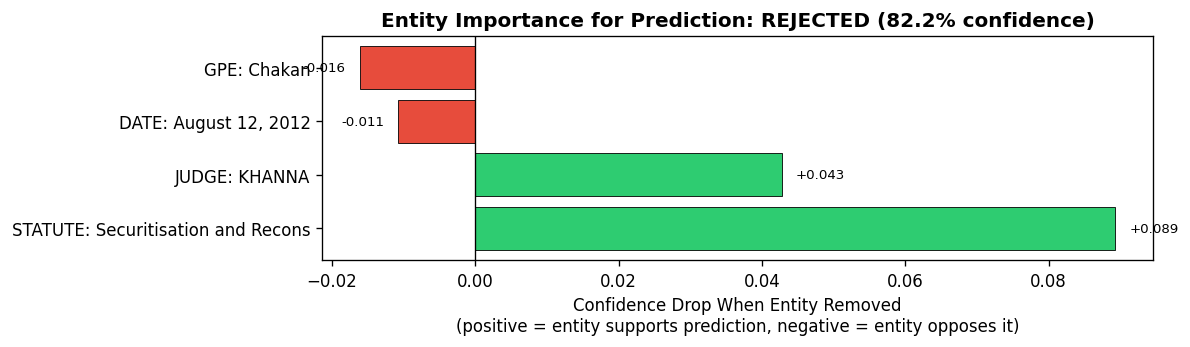

In [8]:
def predict_with_explanation(text: str, true_label: str = None):
    """
    Predicts judgment outcome AND shows which entities
    drove the prediction using attention-based entity scoring.
    """
    import transformers
    transformers.logging.set_verbosity_error()

    # Step 1: NER
    words    = text.split()
    ner_text = ' '.join(words[:200] + words[-200:]) \
               if len(words) > NER_MAX_WORDS else text
    doc        = nlp_ner(ner_text)
    entity_map = defaultdict(list)
    for ent in doc.ents:
        entity_map[ent.label_.upper()].append(ent.text.strip())

    parts = []
    for etype in ENTITY_PRIORITY:
        if etype in entity_map:
            vals = list(dict.fromkeys(entity_map[etype]))[:2]
            parts.append(f'{etype}: {", ".join(vals)}')
    entity_str = ' | '.join(parts) if parts else 'NO_ENTITIES'

    # Step 2: Truncate judgment text
    toks = tokenizer.encode(text, add_special_tokens=False,
                             truncation=False)
    if len(toks) > TEXT_TOKENS:
        toks = toks[:64] + toks[-384:]
    truncated = tokenizer.decode(toks, skip_special_tokens=True)

    # Step 3: Full combined prediction
    combined = f'[ENTITIES] {entity_str} [TEXT] {truncated}'
    enc_full = tokenizer(combined, max_length=512, padding='max_length',
                         truncation=True, return_tensors='pt')
    with torch.no_grad():
        out_full  = model(enc_full['input_ids'].to(DEVICE),
                          enc_full['attention_mask'].to(DEVICE))
        prob_full = torch.softmax(
            out_full['logits'], dim=-1).squeeze().cpu().numpy()

    pred       = ID2LABEL[int(prob_full.argmax())]
    confidence = float(prob_full.max())

    # Step 4: Entity importance — ablation test
    # Remove each entity one at a time and measure confidence drop
    entity_importance = {}
    if parts:
        for i, part in enumerate(parts):
            # Build input without this entity
            remaining = [p for j, p in enumerate(parts) if j != i]
            ablated_str = ' | '.join(remaining) if remaining else 'NO_ENTITIES'
            ablated_combined = f'[ENTITIES] {ablated_str} [TEXT] {truncated}'
            enc_abl = tokenizer(
                ablated_combined, max_length=512,
                padding='max_length', truncation=True,
                return_tensors='pt')
            with torch.no_grad():
                out_abl  = model(enc_abl['input_ids'].to(DEVICE),
                                 enc_abl['attention_mask'].to(DEVICE))
                prob_abl = torch.softmax(
                    out_abl['logits'], dim=-1).squeeze().cpu().numpy()

            # Importance = drop in confidence for predicted class
            pred_idx    = int(prob_full.argmax())
            importance  = float(prob_full[pred_idx] - prob_abl[pred_idx])
            entity_type = part.split(':')[0].strip()
            entity_val  = part.split(':', 1)[1].strip()
            entity_importance[part] = {
                'type'        : entity_type,
                'value'       : entity_val,
                'importance'  : importance,
                'conf_without': float(prob_abl[pred_idx])
            }

    # Sort by importance
    sorted_entities = sorted(
        entity_importance.items(),
        key=lambda x: x[1]['importance'], reverse=True
    )

    # ── Print results ─────────────────────────────────────────
    print('\n' + '='*65)
    print('⚖️  COURT JUDGMENT PREDICTION WITH ENTITY EXPLANATION')
    print('='*65)
    print(f'  Prediction   : {pred}')
    print(f'  Confidence   : {confidence:.2%}')
    print(f'  P(ACCEPTED)  : {prob_full[1]:.2%}')
    print(f'  P(REJECTED)  : {prob_full[0]:.2%}')
    if true_label:
        match = pred == true_label.upper()
        print(f'  True Label   : {true_label.upper()}')
        print(f'  Result       : {"✅ CORRECT" if match else "❌ WRONG"}')

    print(f'\n📋 Extracted Entities ({len(parts)} found):')
    print(f'   {"Entity Type":<15} | {"Entity Value":<40} | {"Importance":>10} | Impact')
    print(f'   {"-"*85}')

    for part, info in sorted_entities:
        imp = info['importance']
        bar = '█' * max(1, int(abs(imp) * 50))
        direction = '▲ helps pred' if imp > 0.01 else \
                    '▼ hurts pred' if imp < -0.01 else '≈ neutral'
        print(f'   {info["type"]:<15} | {info["value"][:40]:<40} | '
              f'{imp:>+10.3f} | {direction}')

    print(f'\n🏆 Most Important Entity:')
    if sorted_entities:
        top = sorted_entities[0][1]
        print(f'   {top["type"]}: {top["value"]}')
        print(f'   Removing it drops confidence by {sorted_entities[0][1]["importance"]:.2%}')

    # ── Bar chart of entity importance ───────────────────────
    if sorted_entities:
        fig, ax = plt.subplots(figsize=(10, max(3, len(sorted_entities)*0.6)))
        labels  = [f'{v["type"]}: {v["value"][:25]}' 
                   for _, v in sorted_entities]
        values  = [v['importance'] for _, v in sorted_entities]
        colors  = ['#2ecc71' if v > 0 else '#e74c3c' for v in values]
        bars    = ax.barh(labels, values, color=colors,
                          edgecolor='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Confidence Drop When Entity Removed\n'
                      '(positive = entity supports prediction, '
                      'negative = entity opposes it)')
        ax.set_title(f'Entity Importance for Prediction: {pred} '
                     f'({confidence:.1%} confidence)',
                     fontweight='bold')
        for bar, val in zip(bars, values):
            ax.text(val + 0.002 if val >= 0 else val - 0.002,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:+.3f}', va='center',
                    ha='left' if val >= 0 else 'right',
                    fontsize=8)
        plt.tight_layout()
        plt.show()

    print('='*65)
    transformers.logging.set_verbosity_warning()


# ── Test on your text ─────────────────────────────────────────
MY_TEXT = """
KHANNA, J. — This appeal arises out of a suit filed by the appellants on August 12, 2012, seeking a declaration that the foreclosure proceedings initiated by the First Respondent were barred by limitation and fundamentally flawed under the Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002 (SARFAESI).

The circumstances leading to this litigation may be stated shortly. The appellants are the successors-in-interest to a vast industrial estate in Chakan, which was mortgaged to the Respondent Corporation in 1988 as security for a term loan of Rs. 5,00,00,000 (Five Crores). By 2005, the account was classified as a Non-Performing Asset (NPA).
"""

predict_with_explanation(MY_TEXT)
# With true label: predict_with_explanation(MY_TEXT, true_label='REJECTED')


⚖️  JUDGMENT PREDICTION — FULL ENTITY EXPLANATION

🎯 FINAL PREDICTION : REJECTED
   Confidence       : 82.16%
   P(ACCEPTED)      : 17.84%
   P(REJECTED)      : 82.16%

📊 WHAT DROVE THE PREDICTION:
   Text alone would predict  : REJECTED (76.52%)
   Entities alone would predict: REJECTED (68.59%)
   Combined (final) prediction : REJECTED (82.16%)

📋 ENTITY CONTRIBUTIONS (ranked by importance):
   #   Type            Value                                 Impact   Explanation
   ----------------------------------------------------------------------------------------------------

   1   STATUTE         Securitisation and Reconstruction o +0.089
       └─ strongly supports REJECTED — removing it drops confidence by 8.9%
          Confidence WITH this entity   : 82.16%
          Confidence WITHOUT this entity: 73.24%

   2   JUDGE           KHANNA                              +0.043
       └─ moderately supports REJECTED — small but meaningful contribution
          Confidence WITH this en

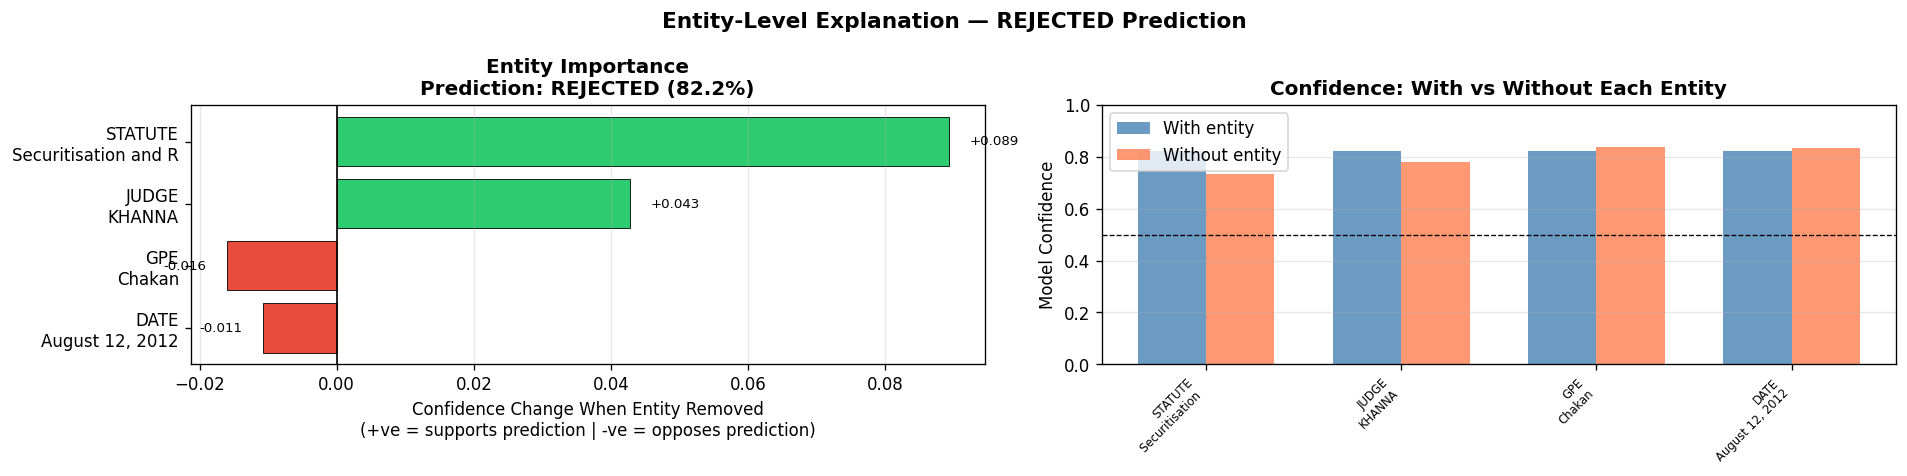

In [9]:
def explain_prediction(text: str, true_label: str = None):
    """
    Full prediction + entity-level explanation using ablation.
    Shows exactly which entity pushed the model toward the prediction.
    """
    import transformers
    transformers.logging.set_verbosity_error()

    # ── Step 1: NER ───────────────────────────────────────────
    words    = text.split()
    ner_text = ' '.join(words[:200] + words[-200:]) \
               if len(words) > NER_MAX_WORDS else text
    doc        = nlp_ner(ner_text)
    entity_map = defaultdict(list)
    for ent in doc.ents:
        entity_map[ent.label_.upper()].append(ent.text.strip())

    parts = []
    for etype in ENTITY_PRIORITY:
        if etype in entity_map:
            vals = list(dict.fromkeys(entity_map[etype]))[:2]
            parts.append(f'{etype}: {", ".join(vals)}')
    entity_str = ' | '.join(parts) if parts else 'NO_ENTITIES'

    # ── Step 2: Truncate judgment text ────────────────────────
    toks = tokenizer.encode(text, add_special_tokens=False,
                             truncation=False)
    if len(toks) > TEXT_TOKENS:
        toks = toks[:64] + toks[-384:]
    truncated = tokenizer.decode(toks, skip_special_tokens=True)

    # ── Step 3: Full prediction ───────────────────────────────
    def get_probs(entity_string, judgment_text):
        combined = f'[ENTITIES] {entity_string} [TEXT] {judgment_text}'
        enc = tokenizer(combined, max_length=512, padding='max_length',
                        truncation=True, return_tensors='pt')
        with torch.no_grad():
            out  = model(enc['input_ids'].to(DEVICE),
                         enc['attention_mask'].to(DEVICE))
            prob = torch.softmax(out['logits'], dim=-1).squeeze().cpu().numpy()
        return prob

    prob_full  = get_probs(entity_str, truncated)
    pred_idx   = int(prob_full.argmax())
    pred       = ID2LABEL[pred_idx]
    confidence = float(prob_full[pred_idx])

    # ── Step 4: Ablation — remove each entity one by one ─────
    entity_scores = []
    for i, part in enumerate(parts):
        remaining    = [p for j, p in enumerate(parts) if j != i]
        ablated_str  = ' | '.join(remaining) if remaining else 'NO_ENTITIES'
        prob_ablated = get_probs(ablated_str, truncated)

        conf_with    = float(prob_full[pred_idx])
        conf_without = float(prob_ablated[pred_idx])
        importance   = conf_with - conf_without  # drop in confidence

        etype = part.split(':')[0].strip()
        eval  = part.split(':', 1)[1].strip()

        # Explain WHY in plain English
        if importance > 0.05:
            reason = f'strongly supports {pred} — removing it drops confidence by {importance:.1%}'
        elif importance > 0.01:
            reason = f'moderately supports {pred} — small but meaningful contribution'
        elif importance < -0.05:
            reason = f'actually works AGAINST {pred} — model predicts {pred} despite this entity'
        elif importance < -0.01:
            reason = f'slightly opposes {pred} — minor pull toward opposite outcome'
        else:
            reason = f'neutral — removing it barely changes the prediction'

        entity_scores.append({
            'type'        : etype,
            'value'       : eval,
            'importance'  : importance,
            'conf_with'   : conf_with,
            'conf_without': conf_without,
            'reason'      : reason
        })

    # ── Step 5: Text-only prediction (no entities) ───────────
    prob_text_only   = get_probs('NO_ENTITIES', truncated)
    pred_text_only   = ID2LABEL[int(prob_text_only.argmax())]
    conf_text_only   = float(prob_text_only.max())

    # ── Step 6: Entities-only prediction (no text) ───────────
    prob_ents_only   = get_probs(entity_str, '')
    pred_ents_only   = ID2LABEL[int(prob_ents_only.argmax())]
    conf_ents_only   = float(prob_ents_only.max())

    # Sort by absolute importance
    entity_scores.sort(key=lambda x: abs(x['importance']), reverse=True)

    # ── Print full explanation ────────────────────────────────
    print('\n' + '='*65)
    print('⚖️  JUDGMENT PREDICTION — FULL ENTITY EXPLANATION')
    print('='*65)
    print(f'\n🎯 FINAL PREDICTION : {pred}')
    print(f'   Confidence       : {confidence:.2%}')
    print(f'   P(ACCEPTED)      : {prob_full[1]:.2%}')
    print(f'   P(REJECTED)      : {prob_full[0]:.2%}')
    if true_label:
        match = pred == true_label.upper()
        print(f'   True Label       : {true_label.upper()}')
        print(f'   Correct          : {"✅ YES" if match else "❌ NO"}')

    print(f'\n📊 WHAT DROVE THE PREDICTION:')
    print(f'   Text alone would predict  : {pred_text_only} ({conf_text_only:.2%})')
    print(f'   Entities alone would predict: {pred_ents_only} ({conf_ents_only:.2%})')
    print(f'   Combined (final) prediction : {pred} ({confidence:.2%})')

    print(f'\n📋 ENTITY CONTRIBUTIONS (ranked by importance):')
    print(f'   {"#":<3} {"Type":<15} {"Value":<35} {"Impact":>8}   Explanation')
    print(f'   {"-"*100}')
    for rank, e in enumerate(entity_scores, 1):
        impact_bar = '██' * max(1, int(abs(e['importance']) * 30))
        sign       = '+' if e['importance'] >= 0 else '-'
        print(f'\n   {rank:<3} {e["type"]:<15} {e["value"][:35]:<35} '
              f'{sign}{abs(e["importance"]):.3f}')
        print(f'       └─ {e["reason"]}')
        print(f'          Confidence WITH this entity   : {e["conf_with"]:.2%}')
        print(f'          Confidence WITHOUT this entity: {e["conf_without"]:.2%}')

    # ── Summary verdict ───────────────────────────────────────
    top        = entity_scores[0]
    supporters = [e for e in entity_scores if e['importance'] > 0.01]
    opposers   = [e for e in entity_scores if e['importance'] < -0.01]

    print(f'\n💡 PLAIN ENGLISH VERDICT:')
    print(f'   The model predicted {pred} primarily because of:')
    print(f'   → {top["type"]}: {top["value"][:50]}')
    print(f'     (most influential entity — {top["reason"]})')
    if supporters:
        print(f'\n   Supporting entities ({len(supporters)}):')
        for e in supporters:
            print(f'   ✅ {e["type"]}: {e["value"][:40]}')
    if opposers:
        print(f'\n   Opposing entities ({len(opposers)}):')
        for e in opposers:
            print(f'   ❌ {e["type"]}: {e["value"][:40]}')
            print(f'      (This entity pulled toward the opposite outcome '
                  f'but was outvoted)')

    # ── Bar chart ─────────────────────────────────────────────
    if entity_scores:
        fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(entity_scores)*0.8)))

        # Importance bar chart
        labels  = [f'{e["type"]}\n{e["value"][:20]}' for e in entity_scores]
        values  = [e['importance'] for e in entity_scores]
        colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
        axes[0].barh(labels[::-1], values[::-1],
                     color=colors[::-1], edgecolor='black', linewidth=0.5)
        axes[0].axvline(0, color='black', linewidth=1)
        axes[0].set_xlabel('Confidence Change When Entity Removed\n'
                           '(+ve = supports prediction | -ve = opposes prediction)')
        axes[0].set_title(f'Entity Importance\nPrediction: {pred} ({confidence:.1%})',
                          fontweight='bold')
        axes[0].grid(True, alpha=0.3, axis='x')
        for i, (val, label) in enumerate(zip(values[::-1], labels[::-1])):
            axes[0].text(val + 0.003 if val >= 0 else val - 0.003,
                         i, f'{val:+.3f}', va='center',
                         ha='left' if val >= 0 else 'right', fontsize=8)

        # Confidence comparison: with vs without each entity
        x       = range(len(entity_scores))
        width   = 0.35
        conf_w  = [e['conf_with']    for e in entity_scores]
        conf_wo = [e['conf_without'] for e in entity_scores]
        xlabels = [f'{e["type"]}\n{e["value"][:15]}' for e in entity_scores]

        axes[1].bar([i - width/2 for i in x], conf_w,  width,
                    label='With entity',    color='steelblue',  alpha=0.8)
        axes[1].bar([i + width/2 for i in x], conf_wo, width,
                    label='Without entity', color='coral',      alpha=0.8)
        axes[1].set_xticks(list(x))
        axes[1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
        axes[1].set_ylabel('Model Confidence')
        axes[1].set_title('Confidence: With vs Without Each Entity',
                          fontweight='bold')
        axes[1].legend()
        axes[1].axhline(0.5, color='black', linestyle='--',
                        linewidth=0.8, label='Decision boundary')
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].set_ylim(0, 1)

        plt.suptitle(f'Entity-Level Explanation — {pred} Prediction',
                     fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.show()

    print('='*65)
    transformers.logging.set_verbosity_warning()


# ── Paste your judgment text below ───────────────────────────
MY_TEXT = """
KHANNA, J. — This appeal arises out of a suit filed by the appellants on August 12, 2012, seeking a declaration that the foreclosure proceedings initiated by the First Respondent were barred by limitation and fundamentally flawed under the Securitisation and Reconstruction of Financial Assets and Enforcement of Security Interest Act, 2002 (SARFAESI).

The circumstances leading to this litigation may be stated shortly. The appellants are the successors-in-interest to a vast industrial estate in Chakan, which was mortgaged to the Respondent Corporation in 1988 as security for a term loan of Rs. 5,00,00,000 (Five Crores). By 2005, the account was classified as a Non-Performing Asset (NPA).
"""

# With known true label:
# explain_prediction(MY_TEXT, true_label='REJECTED')

# Without true label:
explain_prediction(MY_TEXT)

In [10]:
import json, os, ast, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report
)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paths ─────────────────────────────────────────────────────
INPUT_DIR = '/kaggle/input/notebooks/muthangisrirangasai/fwork-1'
DATA_DIR  = '/kaggle/input/datasets/muthangisrirangasai/cjpe-judgment-dataset-jsonl'
WORK_DIR  = '/kaggle/working'

# ── Config ────────────────────────────────────────────────────
LABEL2ID = {'REJECTED': 0, 'ACCEPTED': 1}
ID2LABEL = {0: 'REJECTED', 1: 'ACCEPTED'}
MAX_LEN  = 512
TEXT_TOKENS = 448

# ── Load tokenizer ────────────────────────────────────────────
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(INPUT_DIR)
print('✅ Tokenizer loaded')

# ── Load test data ────────────────────────────────────────────
def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:    records.append(json.loads(line))
            except: records.append(ast.literal_eval(line))
    return records

print('Loading test data...')
test_records = load_jsonl(f'{DATA_DIR}/test.jsonl')
test_texts   = [r['text'].strip() for r in test_records
                if r.get('text') and r.get('label') in LABEL2ID]
test_labels  = [LABEL2ID[r['label']] for r in test_records
                if r.get('text') and r.get('label') in LABEL2ID]
print(f'✅ {len(test_texts):,} test records loaded')

# ── Load NER cache for test ───────────────────────────────────
print('Loading NER cache...')
cache_path = f'{INPUT_DIR}/combined_test.json'
if not os.path.exists(cache_path):
    cache_path = f'{INPUT_DIR}/combined_test.json'
with open(cache_path) as f:
    test_combined = json.load(f)
print(f'✅ NER cache loaded | {len(test_combined):,} records')

assert len(test_combined) == len(test_labels), \
    f'Mismatch: {len(test_combined)} texts vs {len(test_labels)} labels'

# ── Dataset ───────────────────────────────────────────────────
class JudgmentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_dataset = JudgmentDataset(
    test_combined, test_labels, tokenizer, MAX_LEN)
test_loader  = DataLoader(
    test_dataset, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True)
print(f'✅ Test dataset: {len(test_dataset):,} | {len(test_loader)} batches')

# ── Model ─────────────────────────────────────────────────────
class JudgmentClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden    = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        loss   = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {'loss': loss, 'logits': logits}

print('Loading model weights...')
model = JudgmentClassifier('law-ai/InLegalBERT').to(DEVICE)
model.load_state_dict(
    torch.load(f'{INPUT_DIR}/best_finetuned_model.pt', map_location=DEVICE))
model.eval()
print(f'✅ Model loaded | device: {DEVICE}')

# ── Evaluate on full test set ─────────────────────────────────
print('\nRunning evaluation on full test set (1,517 cases)...')
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label']
        out  = model(ids, mask)
        prob = torch.softmax(out['logits'], dim=-1)
        pred = torch.argmax(prob, dim=-1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labs.numpy())
        all_probs.extend(prob[:, 1].cpu().numpy())

# ── Print results ─────────────────────────────────────────────
acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
auc  = roc_auc_score(all_labels, all_probs)

print(f'\n{"="*55}')
print(f'✅ TRUE MODEL ACCURACY — FULL TEST SET (1,517 cases)')
print(f'{"="*55}')
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1 (macro): {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print(f'{"="*55}')
print(f'\nDetailed Classification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=['REJECTED', 'ACCEPTED']
))

Loading tokenizer...
✅ Tokenizer loaded
Loading test data...
✅ 1,517 test records loaded
Loading NER cache...
✅ NER cache loaded | 1,517 records
✅ Test dataset: 1,517 | 48 batches
Loading model weights...
✅ Model loaded | device: cuda

Running evaluation on full test set (1,517 cases)...

✅ TRUE MODEL ACCURACY — FULL TEST SET (1,517 cases)
  Accuracy  : 0.7106  (71.06%)
  F1 (macro): 0.7083
  Precision : 0.7184
  Recall    : 0.7110
  ROC-AUC   : 0.7970

Detailed Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.68      0.80      0.73       755
    ACCEPTED       0.76      0.62      0.68       762

    accuracy                           0.71      1517
   macro avg       0.72      0.71      0.71      1517
weighted avg       0.72      0.71      0.71      1517



In [11]:
import subprocess, sys, os, site

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"{'✅' if result.returncode == 0 else '❌'} {cmd[:70]}")
    if result.returncode != 0:
        print(result.stderr[-200:])

run("pip uninstall -y transformers accelerate datasets tokenizers huggingface-hub")
run("pip uninstall -y transformers accelerate datasets tokenizers huggingface-hub")
run("pip install --upgrade --force-reinstall --no-deps -q huggingface-hub==0.23.4")
run("pip install --upgrade --force-reinstall --no-deps -q tokenizers==0.19.1")
run("pip install --upgrade --force-reinstall --no-deps -q accelerate==0.28.0")
run("pip install --upgrade --force-reinstall --no-deps -q transformers==4.40.2")
run("pip install -q scikit-learn matplotlib seaborn")

for p in site.getsitepackages():
    if p not in sys.path:
        sys.path.insert(0, p)

mods = [m for m in sys.modules if any(
    m.startswith(p) for p in
    ['transformers','accelerate','tokenizers','huggingface_hub'])]
for m in mods: del sys.modules[m]

import accelerate, transformers
from transformers import AutoTokenizer, AutoModel
print(f"✅ accelerate  : {accelerate.__version__}")
print(f"✅ transformers: {transformers.__version__}")
print("✅ Cell 1 done")

✅ pip uninstall -y transformers accelerate datasets tokenizers huggingfa
✅ pip uninstall -y transformers accelerate datasets tokenizers huggingfa
✅ pip install --upgrade --force-reinstall --no-deps -q huggingface-hub==
✅ pip install --upgrade --force-reinstall --no-deps -q tokenizers==0.19.
✅ pip install --upgrade --force-reinstall --no-deps -q accelerate==0.28.
✅ pip install --upgrade --force-reinstall --no-deps -q transformers==4.4
✅ pip install -q scikit-learn matplotlib seaborn
✅ accelerate  : 0.28.0
✅ transformers: 4.40.2
✅ Cell 1 done


In [12]:
import os

INPUT_DIR = '/kaggle/input/notebooks/muthangisrirangasai/fwork-1'
DATA_DIR  = '/kaggle/input/datasets/muthangisrirangasai/cjpe-judgment-dataset-jsonl'

print('📁 Checking available files...')
key_files = {
    'best_finetuned_model.pt' : f'{INPUT_DIR}/best_finetuned_model.pt',
    'combined_train.json'     : f'{INPUT_DIR}/combined_train.json',
    'combined_dev.json'       : f'{INPUT_DIR}/combined_dev.json',
    'combined_test.json'      : f'{INPUT_DIR}/combined_test.json',
    'tokenizer'               : INPUT_DIR,
    'multi_train.jsonl'       : f'{DATA_DIR}/multi_train.jsonl',
    'test.jsonl'              : f'{DATA_DIR}/test.jsonl',
}

all_ok = True
for name, path in key_files.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e6 if exists and os.path.isfile(path) else 0
    print(f'  {"✅" if exists else "❌"} {name:<30}: {size:.1f} MB')
    if not exists:
        all_ok = False

print(f'\n{"✅ All files found" if all_ok else "❌ Some files missing"}')
print(f'\nStrategy: Retrain on FULL 32k dataset from saved model weights')
print(f'Expected improvement: +3-5% accuracy on test set')

📁 Checking available files...
  ✅ best_finetuned_model.pt       : 438.8 MB
  ✅ combined_train.json           : 73.9 MB
  ✅ combined_dev.json             : 2.3 MB
  ✅ combined_test.json            : 3.5 MB
  ✅ tokenizer                     : 0.0 MB
  ✅ multi_train.jsonl             : 614.6 MB
  ✅ test.jsonl                    : 35.2 MB

✅ All files found

Strategy: Retrain on FULL 32k dataset from saved model weights
Expected improvement: +3-5% accuracy on test set


In [13]:
import json, os, ast, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report
)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_DIR = '/kaggle/input/notebooks/muthangisrirangasai/fwork-1'
DATA_DIR  = '/kaggle/input/datasets/muthangisrirangasai/cjpe-judgment-dataset-jsonl'
OUTPUT_DIR = '/kaggle/working/retrain_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'✅ Device: {DEVICE} | {torch.cuda.get_device_name(0)}')

# ── Config ────────────────────────────────────────────────────
class CFG:
    MODEL_NAME   = 'law-ai/InLegalBERT'
    MAX_LEN      = 512
    BATCH_SIZE   = 16
    GRAD_ACCUM   = 2           # effective batch = 32
    EPOCHS       = 5
    LR           = 1e-5        # lower LR since continuing from checkpoint
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    DROPOUT      = 0.3
    SEED         = 42
    LABEL2ID     = {'REJECTED': 0, 'ACCEPTED': 1}
    ID2LABEL     = {0: 'REJECTED', 1: 'ACCEPTED'}

torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
random.seed(CFG.SEED)
torch.cuda.manual_seed_all(CFG.SEED)

# ── Load data ─────────────────────────────────────────────────
def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:    records.append(json.loads(line))
            except: records.append(ast.literal_eval(line))
    return records

def load_split(combined_path, jsonl_path, split_name):
    recs   = load_jsonl(jsonl_path)
    labels = [CFG.LABEL2ID[r['label']] for r in recs
              if r.get('text') and r.get('label') in CFG.LABEL2ID]
    with open(combined_path) as f:
        texts = json.load(f)
    assert len(texts) == len(labels), \
        f'Mismatch: {len(texts)} texts vs {len(labels)} labels'
    df = pd.DataFrame({'text': texts, 'label': labels})
    print(f'  [{split_name}] {len(df):,} | '
          f'{df["label"].value_counts().to_dict()}')
    return df

print('\nLoading data...')
train_df = load_split(
    f'{INPUT_DIR}/combined_train.json',
    f'{DATA_DIR}/multi_train.jsonl', 'train')   # FULL 32k
dev_df = load_split(
    f'{INPUT_DIR}/combined_dev.json',
    f'{DATA_DIR}/multi_dev.jsonl', 'dev')
test_df = load_split(
    f'{INPUT_DIR}/combined_test.json',
    f'{DATA_DIR}/test.jsonl', 'test')

# ── Class weights ─────────────────────────────────────────────
n_rej = (train_df['label'] == 0).sum()
n_acc = (train_df['label'] == 1).sum()
class_weights = torch.tensor(
    [len(train_df)/(2*n_rej), len(train_df)/(2*n_acc)],
    dtype=torch.float32).to(DEVICE)
print(f'\nClass weights: REJECTED={class_weights[0]:.3f} | '
      f'ACCEPTED={class_weights[1]:.3f}')

# ── Tokenizer ─────────────────────────────────────────────────
print('\nLoading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(INPUT_DIR)
print('✅ Tokenizer loaded')

# ── Dataset ───────────────────────────────────────────────────
class JudgmentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True,
            return_tensors='pt')
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = JudgmentDataset(
    train_df['text'].tolist(), train_df['label'].tolist(),
    tokenizer, CFG.MAX_LEN)
dev_dataset = JudgmentDataset(
    dev_df['text'].tolist(), dev_df['label'].tolist(),
    tokenizer, CFG.MAX_LEN)
test_dataset = JudgmentDataset(
    test_df['text'].tolist(), test_df['label'].tolist(),
    tokenizer, CFG.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE,
                          shuffle=True, num_workers=2,
                          pin_memory=True, drop_last=True)
dev_loader   = DataLoader(dev_dataset, batch_size=CFG.BATCH_SIZE*2,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE*2,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'\n✅ Datasets ready')
print(f'   Train : {len(train_dataset):,} | {len(train_loader)} batches')
print(f'   Dev   : {len(dev_dataset):,}  | {len(dev_loader)} batches')
print(f'   Test  : {len(test_dataset):,} | {len(test_loader)} batches')

est = len(train_loader) * 2 * CFG.EPOCHS / 60
print(f'\n⏱️  Estimated time: ~{est:.0f} mins')

# ── Model ─────────────────────────────────────────────────────
class JudgmentClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden    = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        out    = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask)
        cls    = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        loss   = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(
                weight=class_weights)(logits, labels)
        return {'loss': loss, 'logits': logits}

# Load from saved checkpoint
print('\nLoading saved model weights...')
model = JudgmentClassifier(CFG.MODEL_NAME, CFG.DROPOUT).to(DEVICE)
model.load_state_dict(
    torch.load(f'{INPUT_DIR}/best_finetuned_model.pt',
               map_location=DEVICE))
print('✅ Loaded from checkpoint — continuing training on full 32k')

# ── Optimizer & Scheduler ─────────────────────────────────────
optimizer    = AdamW(model.parameters(),
                     lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
total_steps  = (len(train_loader) // CFG.GRAD_ACCUM) * CFG.EPOCHS
warmup_steps = int(total_steps * CFG.WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps)
print(f'   Total steps : {total_steps:,}')
print(f'   Warmup steps: {warmup_steps:,}')

# ── Evaluate function ─────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)
            out  = model(ids, mask)
            prob = torch.softmax(out['logits'], dim=-1)
            pred = torch.argmax(prob, dim=-1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(prob[:, 1].cpu().numpy())
    return {
        'accuracy' : accuracy_score(all_labels, all_preds),
        'f1'       : f1_score(all_labels, all_preds,
                              average='macro', zero_division=0),
        'precision': precision_score(all_labels, all_preds,
                                     average='macro', zero_division=0),
        'recall'   : recall_score(all_labels, all_preds,
                                  average='macro', zero_division=0),
        'roc_auc'  : roc_auc_score(all_labels, all_probs),
        'preds'    : all_preds,
        'labels'   : all_labels,
        'probs'    : all_probs
    }

# ── Training loop ─────────────────────────────────────────────
best_f1         = 0.0
best_model_path = f'{OUTPUT_DIR}/best_model_32k.pt'
patience        = 2
patience_ctr    = 0
history         = {'train_loss':[], 'dev_f1':[], 'dev_acc':[], 'dev_auc':[]}

print('\n' + '='*60)
print('🏋️  Retraining on FULL 32k dataset')
print(f'   Epochs    : {CFG.EPOCHS}')
print(f'   LR        : {CFG.LR} (continuing from checkpoint)')
print(f'   Eff. Batch: {CFG.BATCH_SIZE * CFG.GRAD_ACCUM}')
print('='*60)

for epoch in range(CFG.EPOCHS):
    print(f'\n📅 Epoch {epoch+1}/{CFG.EPOCHS}')
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label'].to(DEVICE)
        out  = model(ids, mask, labs)
        loss = out['loss'] / CFG.GRAD_ACCUM
        loss.backward()
        total_loss += out['loss'].item()

        if (step+1) % CFG.GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        if (step+1) % 200 == 0:
            print(f'   step {step+1}/{len(train_loader)} '
                  f'| loss: {out["loss"].item():.4f}')

    avg_loss    = total_loss / len(train_loader)
    dev_metrics = evaluate(model, dev_loader)

    history['train_loss'].append(avg_loss)
    history['dev_f1'].append(dev_metrics['f1'])
    history['dev_acc'].append(dev_metrics['accuracy'])
    history['dev_auc'].append(dev_metrics['roc_auc'])

    print(f'\n   Train Loss : {avg_loss:.4f}')
    print(f'   Dev Acc    : {dev_metrics["accuracy"]:.4f}')
    print(f'   Dev F1     : {dev_metrics["f1"]:.4f}')
    print(f'   Dev AUC    : {dev_metrics["roc_auc"]:.4f}')

    if dev_metrics['f1'] > best_f1:
        best_f1 = dev_metrics['f1']
        torch.save(model.state_dict(), best_model_path)
        print(f'   💾 Best model saved (F1={best_f1:.4f})')
        patience_ctr = 0
    else:
        patience_ctr += 1
        print(f'   ⚠️  No improvement ({patience_ctr}/{patience})')
        if patience_ctr >= patience:
            print('   🛑 Early stopping')
            break

# ── Final test evaluation ─────────────────────────────────────
print('\nLoading best model for final test evaluation...')
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_metrics = evaluate(model, test_loader)

print(f'\n{"="*55}')
print(f'🏆 FINAL TEST SET ACCURACY (1,517 unseen cases)')
print(f'{"="*55}')
print(f'  Accuracy  : {test_metrics["accuracy"]:.4f} '
      f'({test_metrics["accuracy"]*100:.2f}%)')
print(f'  F1 (macro): {test_metrics["f1"]:.4f}')
print(f'  Precision : {test_metrics["precision"]:.4f}')
print(f'  Recall    : {test_metrics["recall"]:.4f}')
print(f'  ROC-AUC   : {test_metrics["roc_auc"]:.4f}')
print(f'{"="*55}')
print(f'\nDetailed Classification Report:')
print(classification_report(
    test_metrics['labels'], test_metrics['preds'],
    target_names=['REJECTED', 'ACCEPTED']
))

# Save best model
torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model_32k.pt')
tokenizer.save_pretrained(f'{OUTPUT_DIR}/tokenizer')
with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'✅ Model saved to {OUTPUT_DIR}')
print(f'💾 Save version to commit outputs!')

✅ Device: cuda | Tesla T4

Loading data...
  [train] 32,305 | {0: 18920, 1: 13385}
  [dev] 994 | {0: 497, 1: 497}
  [test] 1,517 | {1: 762, 0: 755}

Class weights: REJECTED=0.854 | ACCEPTED=1.207

Loading tokenizer...
✅ Tokenizer loaded

✅ Datasets ready
   Train : 32,305 | 2019 batches
   Dev   : 994  | 32 batches
   Test  : 1,517 | 48 batches

⏱️  Estimated time: ~336 mins

Loading saved model weights...
✅ Loaded from checkpoint — continuing training on full 32k
   Total steps : 5,045
   Warmup steps: 504

🏋️  Retraining on FULL 32k dataset
   Epochs    : 5
   LR        : 1e-05 (continuing from checkpoint)
   Eff. Batch: 32

📅 Epoch 1/5
   step 200/2019 | loss: 0.4832
   step 400/2019 | loss: 0.5801
   step 600/2019 | loss: 0.6067
   step 800/2019 | loss: 0.7102
   step 1000/2019 | loss: 0.3415
   step 1200/2019 | loss: 0.2182
   step 1400/2019 | loss: 0.4339
   step 1600/2019 | loss: 0.3071
   step 1800/2019 | loss: 0.3731
   step 2000/2019 | loss: 0.5710

   Train Loss : 0.4956
   

In [14]:
import os, shutil

# Confirm what's in working directory
print('📁 Files in /kaggle/working:')
for f in sorted(os.listdir('/kaggle/working')):
    path = os.path.join('/kaggle/working', f)
    if os.path.isfile(path):
        print(f'  {f} — {os.path.getsize(path)/1e6:.1f} MB')
    else:
        print(f'  {f}/ (folder)')

📁 Files in /kaggle/working:
  __notebook__.ipynb — 0.6 MB
  retrain_output/ (folder)
